# **YouTube Trending Video Dataset (US) Analysis**
- **Author:** Armin Abbasi Najarzadeh
- **Email:** apmnh.armin@gmail.com

# Importing Libraries & Initialization

In [ ]:
import io
import re
import json
import hashlib
import warnings
from collections import Counter

import pandas as pd
import numpy as np
import xgboost as xgb
from textblob import TextBlob
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import chisquare, kruskal, mannwhitneyu

import squarify
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'lines.antialiased': True,
    'patch.antialiased': True,
    'text.antialiased': True,
    'agg.path.chunksize': 10000
})

nirnroot = LinearSegmentedColormap.from_list(
    "nirnroot", 
    ['darkslategrey', 'lightcyan', 'azure', 'mistyrose', 'lightcoral', 'crimson'],
)

freezingflame = LinearSegmentedColormap.from_list(
    "freezingflame", 
    ['blue', 'skyblue', 'lightcyan', 'papayawhip', 'navajowhite', 'darkorange'],
)

# Data Loading and Cleaning
- **Dataset Import**: The US dataset (`USvideos.csv`) is read, along with the category ID mapping provided in a JSON file.
- **Category Mapping**: Video categories are mapped from `category_id` to descriptive names using the JSON metadata.
- **Date Conversion**: 
  - The `trending_date` and `publish_time` columns are converted to datetime format.
  - Additional temporal features, including `publish_day` and `publish_hour`, are extracted from `publish_time`.
- **Engagement Metrics**:  
  - `like_ratio` and `dislike_ratio` are computed to reflect user feedback.
  - An `engagement_score` is calculated to quantify audience interaction relative to view count.
- **Content Features**:
  - The length of each video title and description is measured.
  - The number of tags is determined by counting tag separators.
- **Temporal Categorization**:
  - The `publish_hour` is categorized into four time-of-day segments: *MidNight*, *Morning*, *Afternoon*, and *Evening*.
  - A list of weekdays is defined for potential ordering in visualizations.

In [3]:
us_df = pd.read_csv("/kaggle/input/youtube-new/USvideos.csv", encoding='latin-1')

with open("/kaggle/input/youtube-new/US_category_id.json") as f:
    categories = json.load(f)
    cat_mapping = {int(item['id']): item['snippet']['title'] for item in categories['items']}

us_df['category'] = us_df['category_id'].map(cat_mapping)

us_df['trending_date'] = pd.to_datetime(us_df['trending_date'], format='%y.%d.%m')
us_df['publish_time'] = pd.to_datetime(us_df['publish_time'])

us_df['publish_day'] = us_df['publish_time'].dt.day_name()
us_df['publish_hour'] = us_df['publish_time'].dt.hour

us_df['trending_day'] = us_df['trending_date'].dt.day_name()

us_df['dislike_ratio'] = us_df['dislikes'] / (us_df['likes'] + us_df['dislikes']).replace(0, np.nan)
us_df['like_ratio'] = us_df['likes'] / (us_df['likes'] + us_df['dislikes']).replace(0, np.nan)

us_df['like_view_ratio'] = us_df['likes'] / us_df['views'].replace(0, np.nan)

us_df['engagement_score'] = ((us_df['likes'] + us_df['dislikes'] + us_df['comment_count']) / us_df['views'].replace(0, np.nan)) * 100

us_df['title_length'] = us_df['title'].apply(len)
us_df['description_length'] = us_df['description'].fillna('').apply(len)
us_df['tag_count'] = us_df['tags'].apply(lambda x: len(str(x).split('|')))

daily_quarters = ['MidNight', 'Morning', 'Afternoon', 'Evening']

us_df['time_of_day'] = pd.cut(
    us_df['publish_hour'],
    bins=[0, 6, 12, 18, 24],
    labels=daily_quarters,
    right=False
)

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [4]:
class FigRecorder:
    def __init__(self):
        self.records = dict()

    def hash_fig(self, figure):
        buffer = io.BytesIO()
        figure.savefig(buffer, format='png')
        
        return hashlib.sha256(buffer.getvalue()).hexdigest()
        
    def add(self, figure):
        if (key := self.hash_fig(figure)) not in self.records:
            self.records[key] = figure

    def get_figures(self):
        return list(self.records.values())

    def save_figures(self):
        for idx, figure in enumerate(self.records.values()):
            figure.savefig(f"fig{idx}.png", dpi=300, bbox_inches='tight')
            

In [5]:
fig_recorder = FigRecorder()

# Exploratory Data Analysis

#### Distributional Insights
- Distributions of **views**, **likes**, and **dislikes** were plotted on a logarithmic x-axis to reveal skewed distributions.
- Metric totals and medians were compared across **video categories** using stem plots.

#### Channel and Category Highlights
- A treemap was employed to highlight the **top 10 trending channels** by count.
- A bar chart presented the most frequently trending **video categories** in the U.S. dataset.

#### Temporal Analysis
- The **publish day distribution** and **publish hour distribution** of videos were visualized.
- Median engagement scores were plotted across:
  - Days of the week (radar plot)
  - Hours of the day (lollipop plot)
  - Time-of-day categories (e.g., Morning, Afternoon; radar plot)

#### Dislike Ratio vs. Engagement
- A joint scatter + KDE plot was created to explore the relationship between **dislike ratio** and **engagement score**, colored by category, overlaid with density contours.

#### Tag and Title/Description Analysis
- The **top 20 most common tags** were identified and visualized via a bar chart.
- Engagement score trends were examined across:
  - **Title length** bins (area plot)
  - **Description length** bins (area plot)
  - **Tag count** bins (lollipop plot)
  - **Title vs. Description length** using a 2D heatmap of median engagement

#### Top Channel Performance
- Among the top 10 trending channels, **median engagement scores** were compared using a lollipop plot.

#### Negative Feedback Patterns
- **Dislike ratio medians** were computed and compared across video categories, revealing content types prone to higher viewer disapproval.

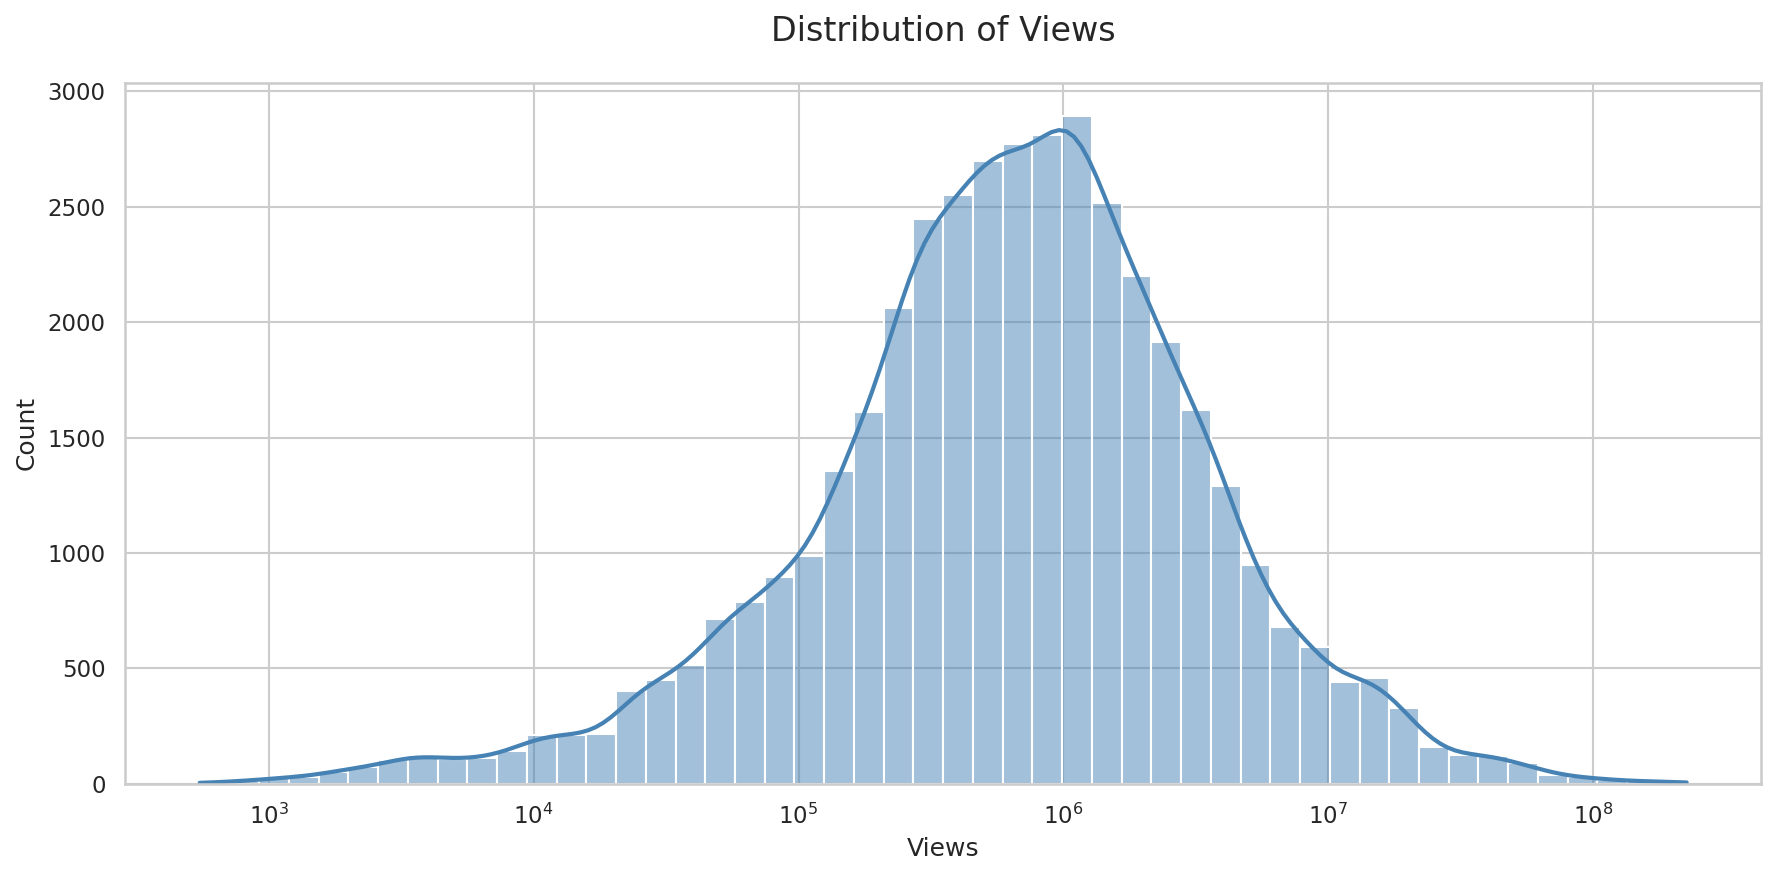

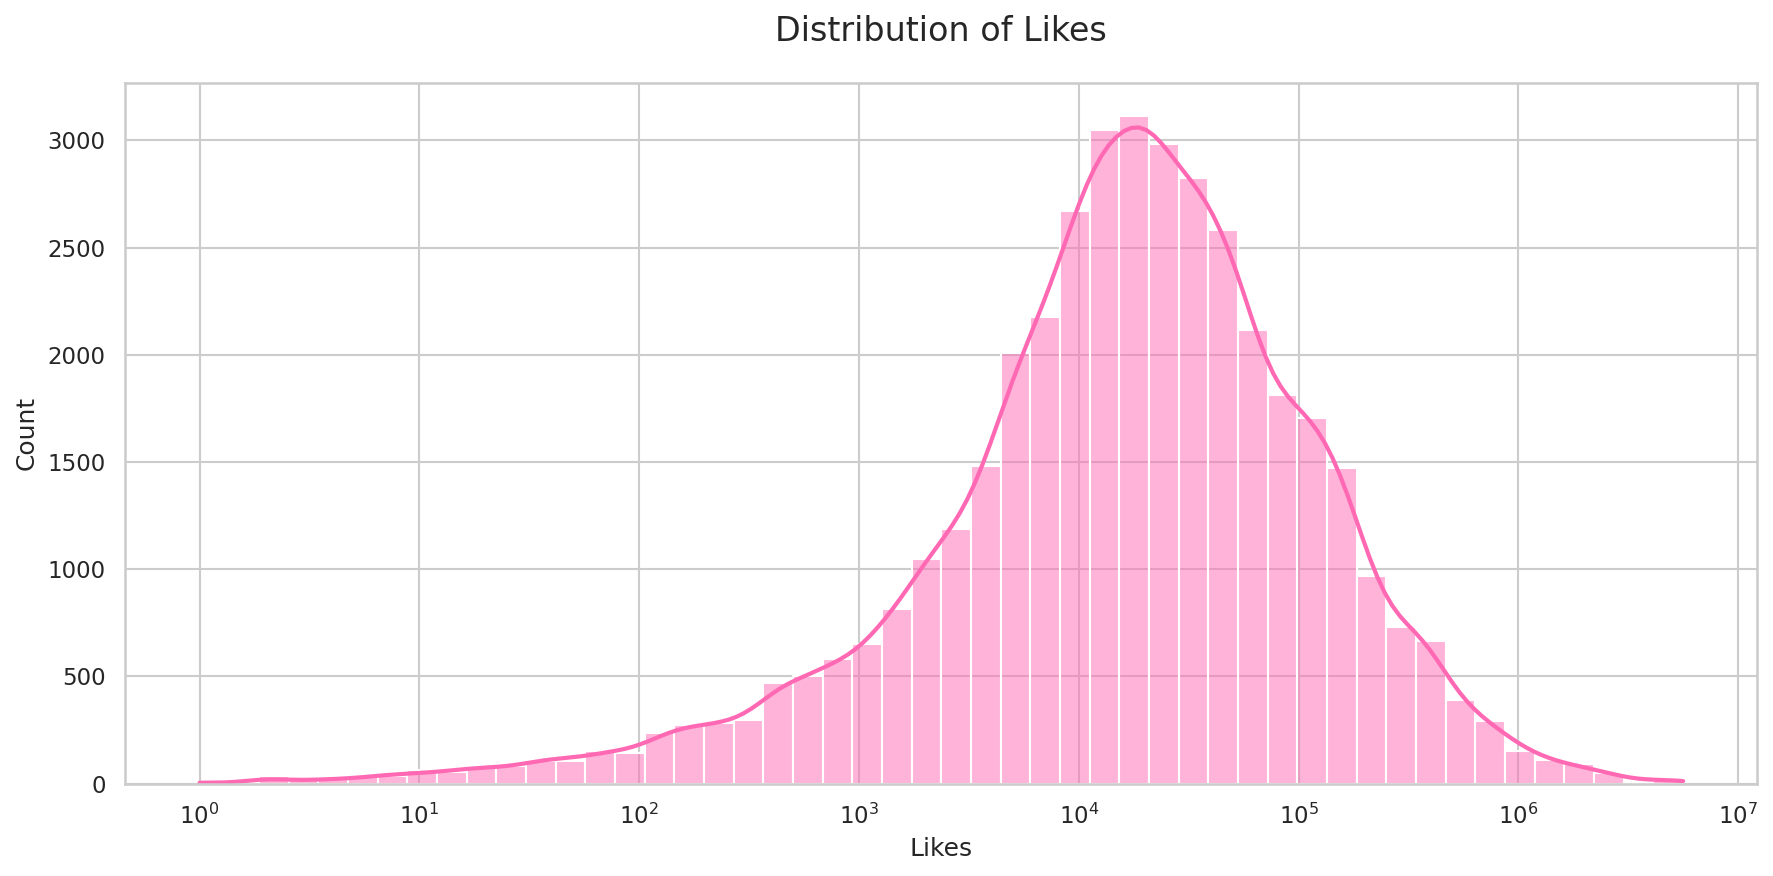

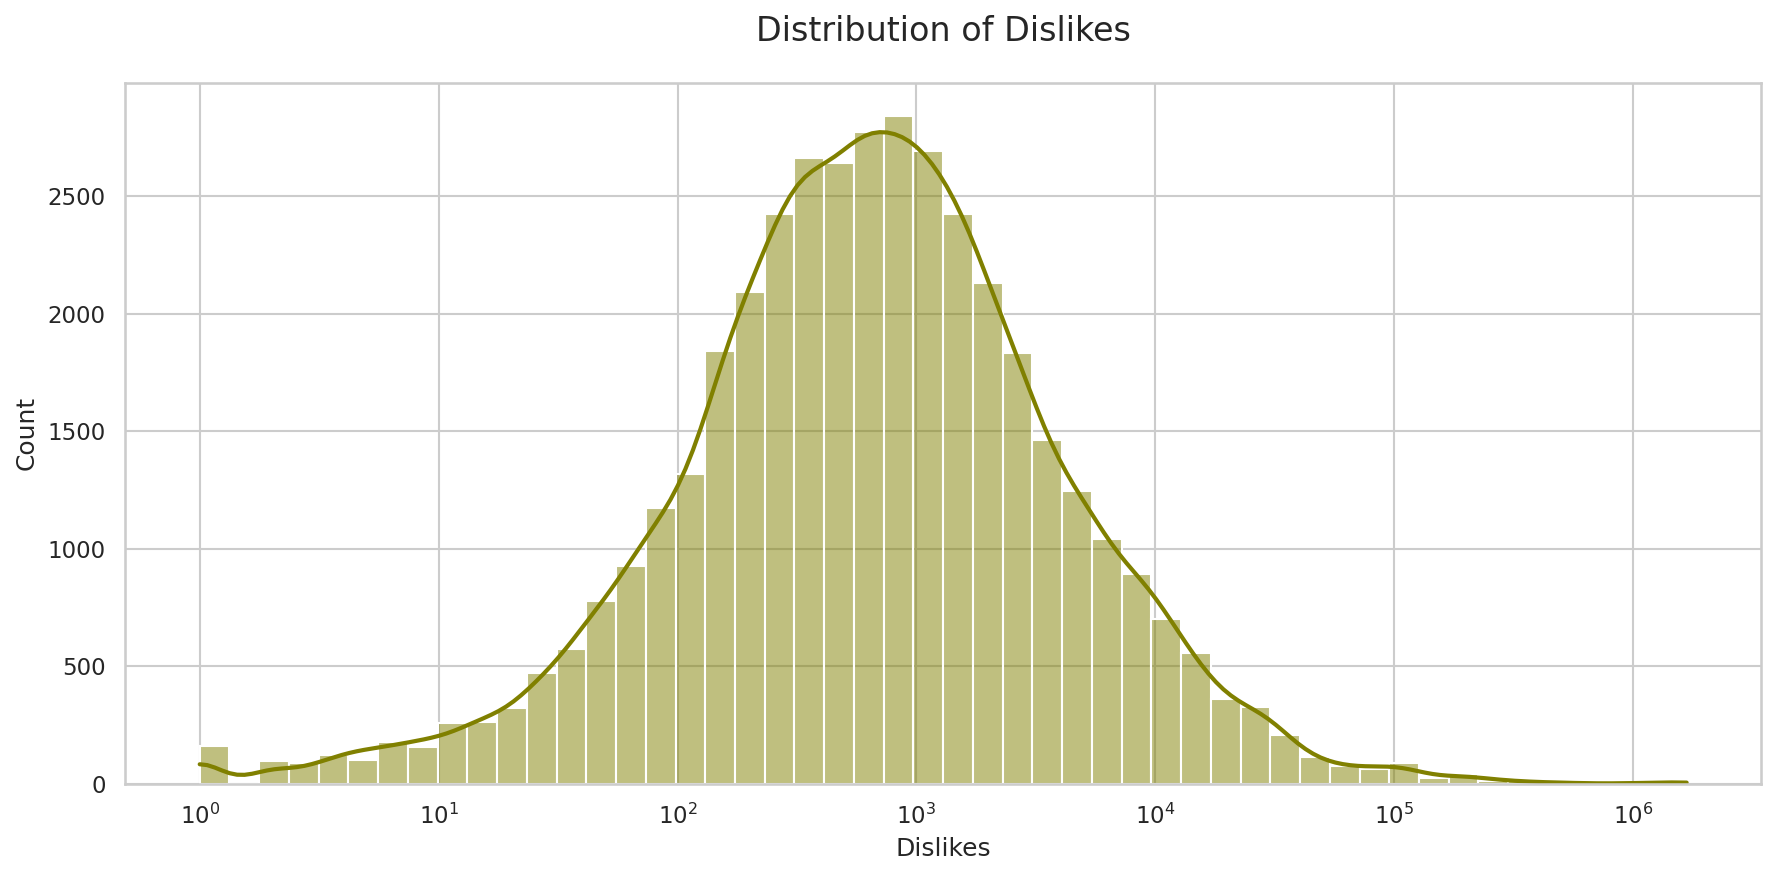

In [6]:
metrics = ['views', 'likes', 'dislikes']
color_map = dict(zip(metrics, ['steelblue', 'hotpink', 'olive']))

for metric in metrics:
    fig = plt.figure()
    valid_data = us_df[us_df[metric] > 0][metric]
    
    sns.histplot(valid_data, bins=50, kde=True, log_scale=(True, False), color=color_map[metric])
    plt.title(f"Distribution of {metric.title()}", size=16, pad=20)
    plt.xlabel(metric.title())
    plt.ylabel("Count")

    fig_recorder.add(fig)
    
    fig.tight_layout()
    fig.show()

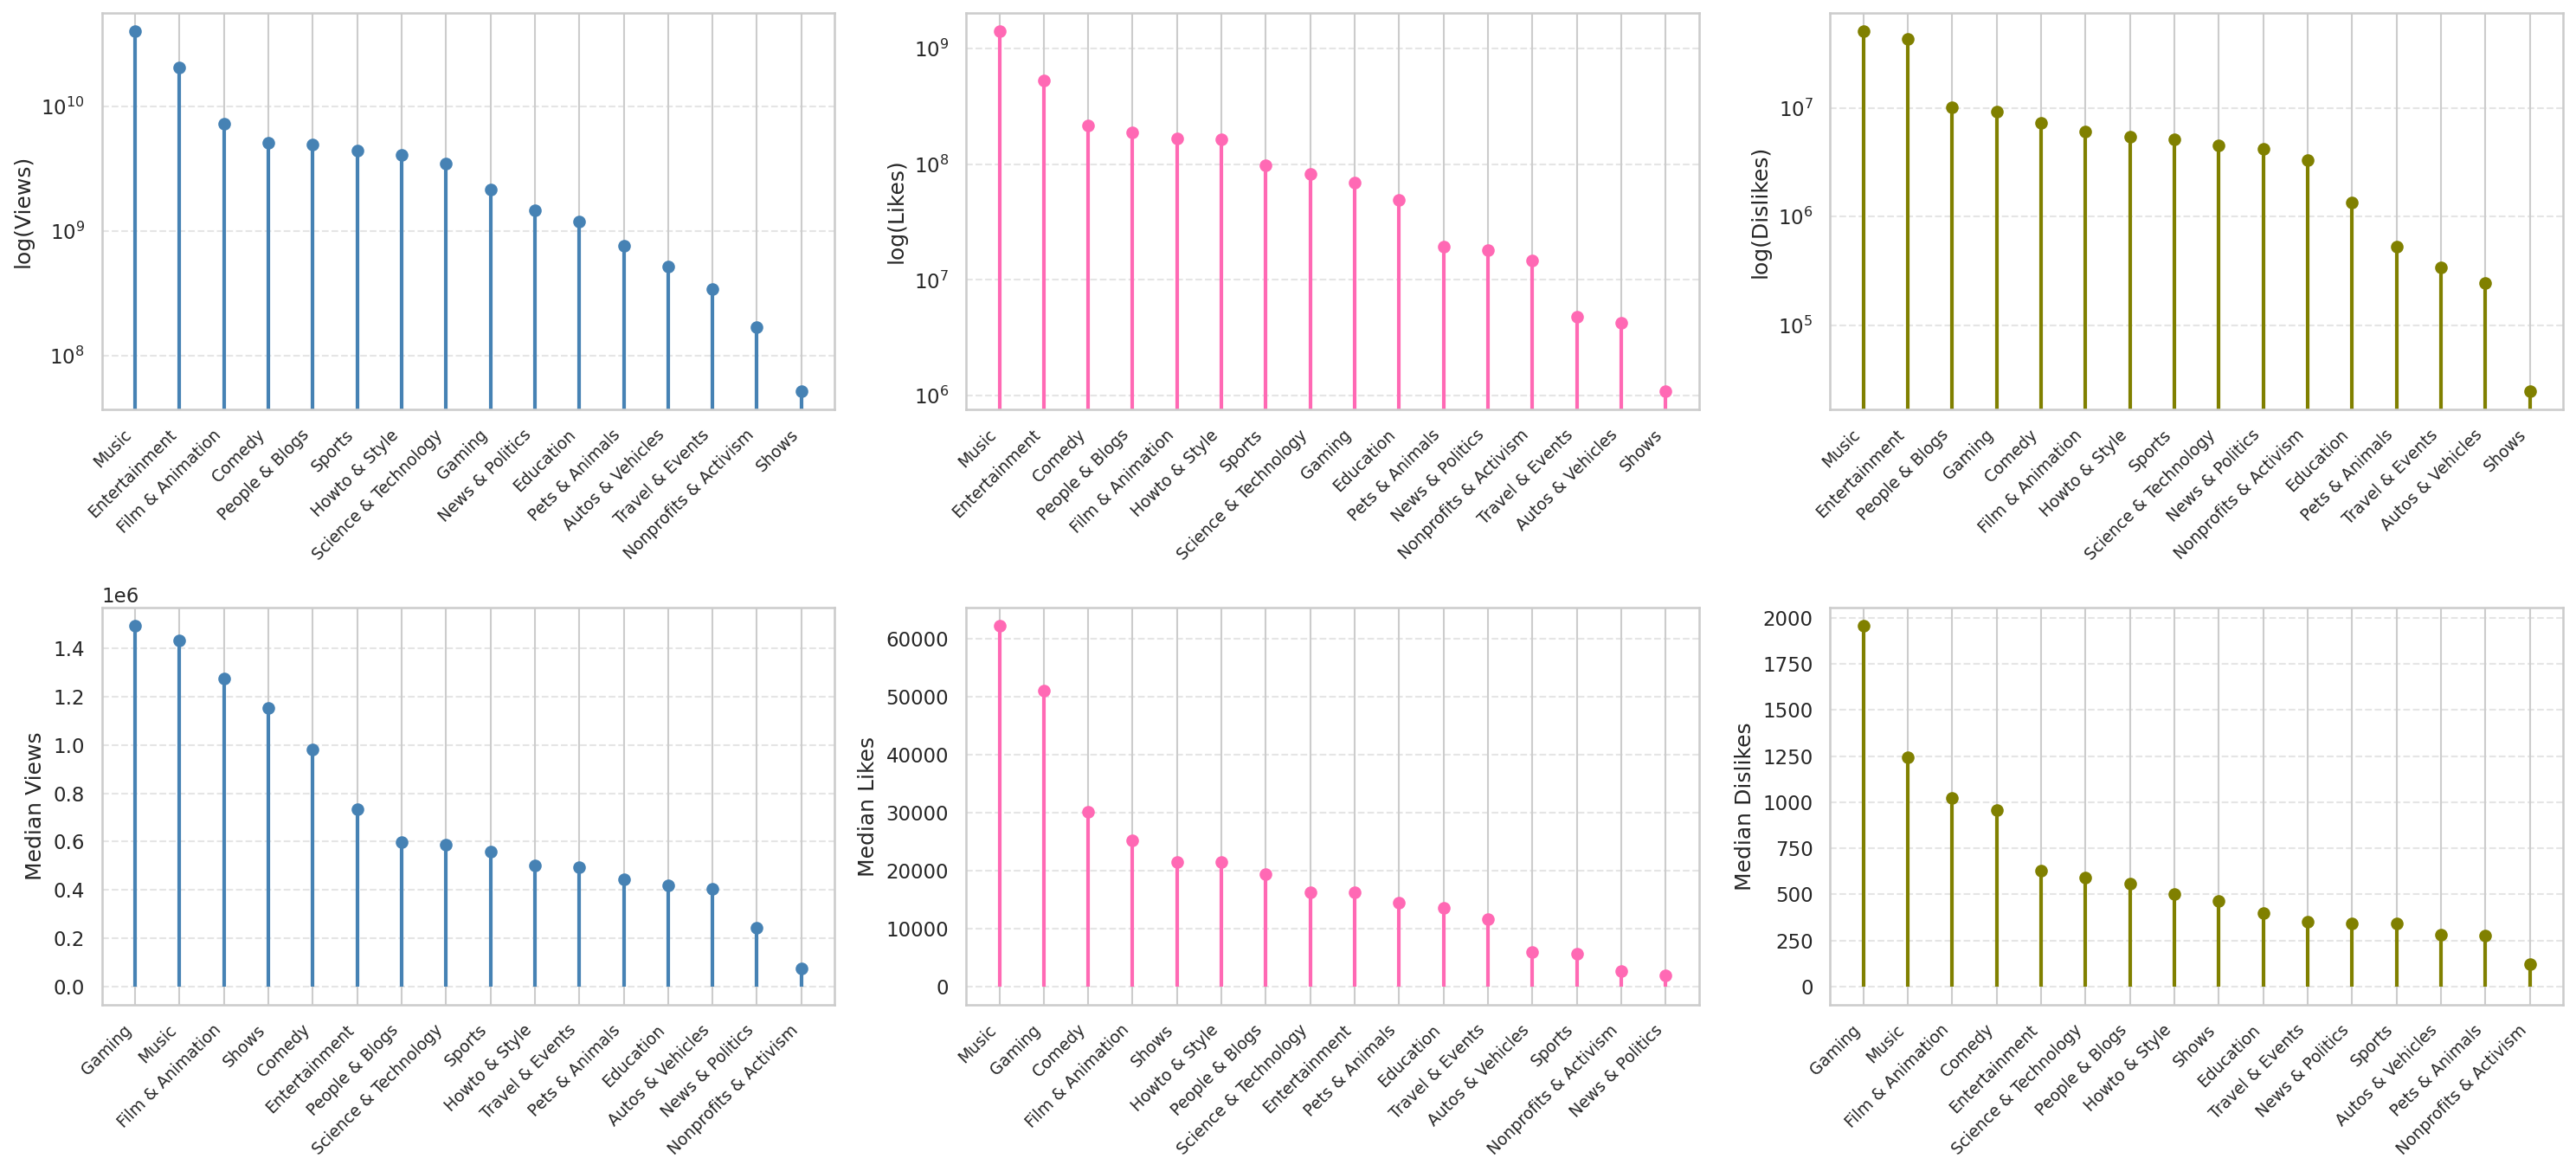

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for idx, metric in enumerate(metrics):
    ax = axes[0, idx % 3]
    metric_by_category = us_df.groupby('category')[metric].sum().reset_index()
    metric_by_category = metric_by_category.sort_values(by=metric, ascending=False)
    
    ax.stem(
        metric_by_category['category'],
        metric_by_category[metric],
        basefmt=" ",
        linefmt=color_map[metric],
        markerfmt="o"
    )
    
    ax.set_ylabel(f"log({metric.capitalize()})")
    ax.set_yscale('log')
    ax.set_xticks(range(len(metric_by_category)))
    ax.set_xticklabels(metric_by_category['category'], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    ax = axes[1, idx % 3]
    metric_by_category = us_df.groupby('category')[metric].median().reset_index()
    metric_by_category = metric_by_category.sort_values(by=metric, ascending=False)
    
    ax.stem(
        metric_by_category['category'],
        metric_by_category[metric],
        basefmt=" ",
        linefmt=color_map[metric],
        markerfmt="o"
    )
    
    ax.set_ylabel(f"Median {metric.capitalize()}")
    ax.set_xticks(range(len(metric_by_category)))
    ax.set_xticklabels(metric_by_category['category'], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)


fig_recorder.add(fig)

fig.tight_layout()
fig.subplots_adjust(top=0.90, hspace=0.5)
fig.show()

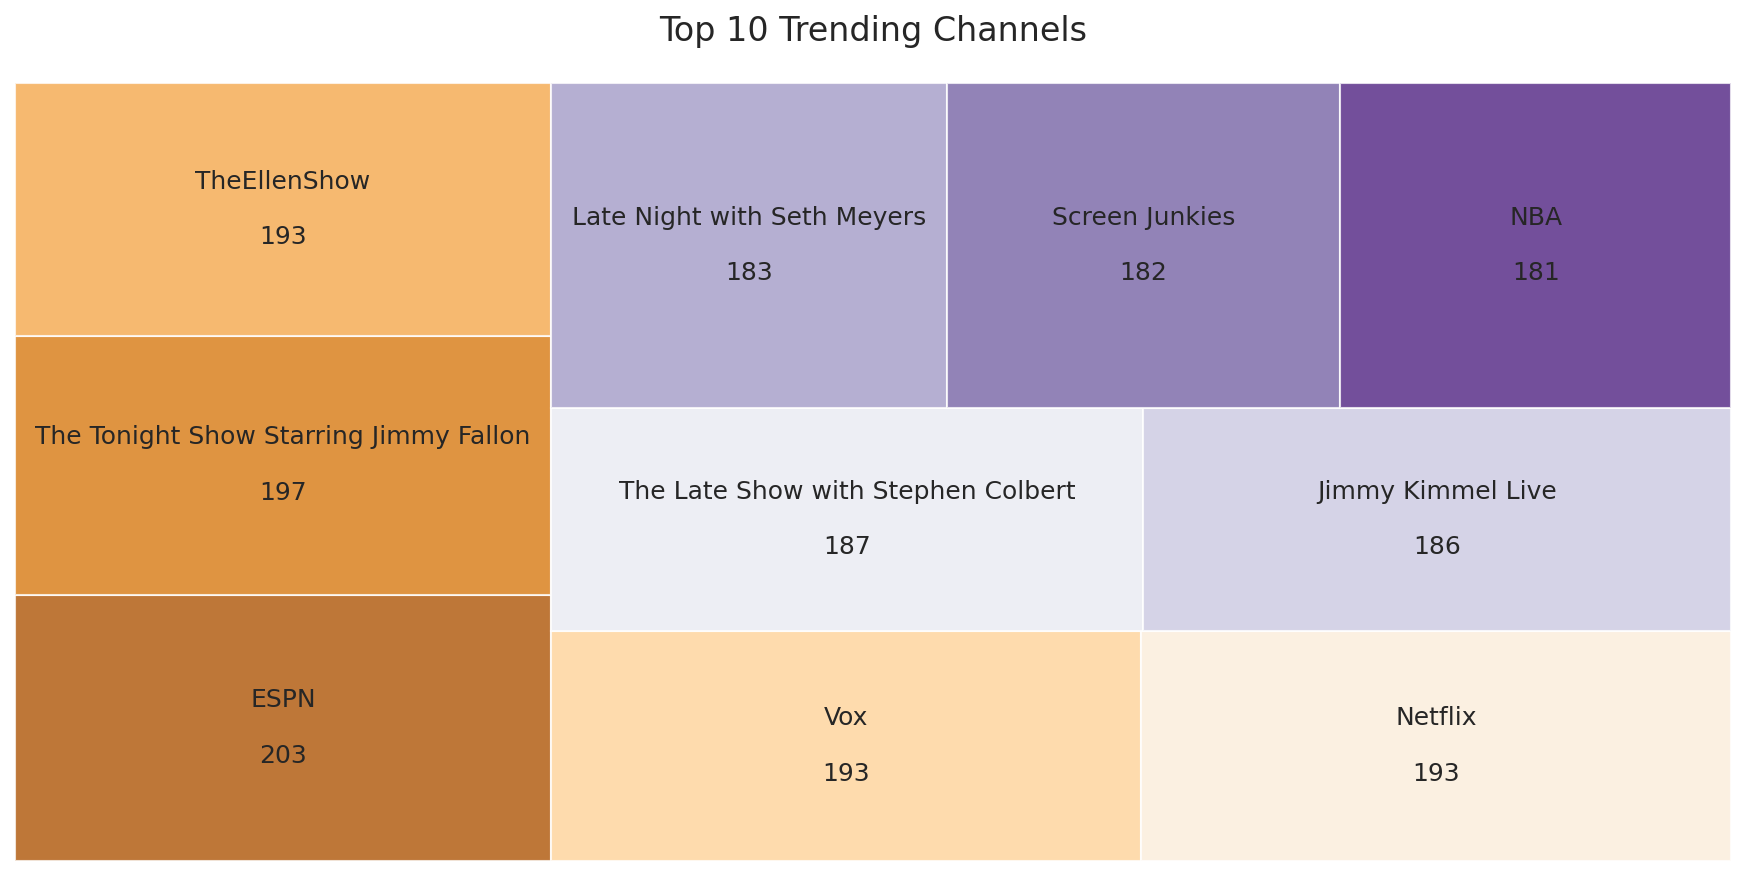

In [8]:
top_channels = us_df['channel_title'].value_counts().head(10)
labels = [f"{label}\n\n{count}" for label, count in zip(top_channels.index, top_channels.values)]

fig = plt.figure()
squarify.plot(sizes=top_channels.values, label=labels, color=sns.color_palette("PuOr", len(top_channels)), alpha=0.8)
plt.title("Top 10 Trending Channels", size=16, pad=20)
plt.axis('off')

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

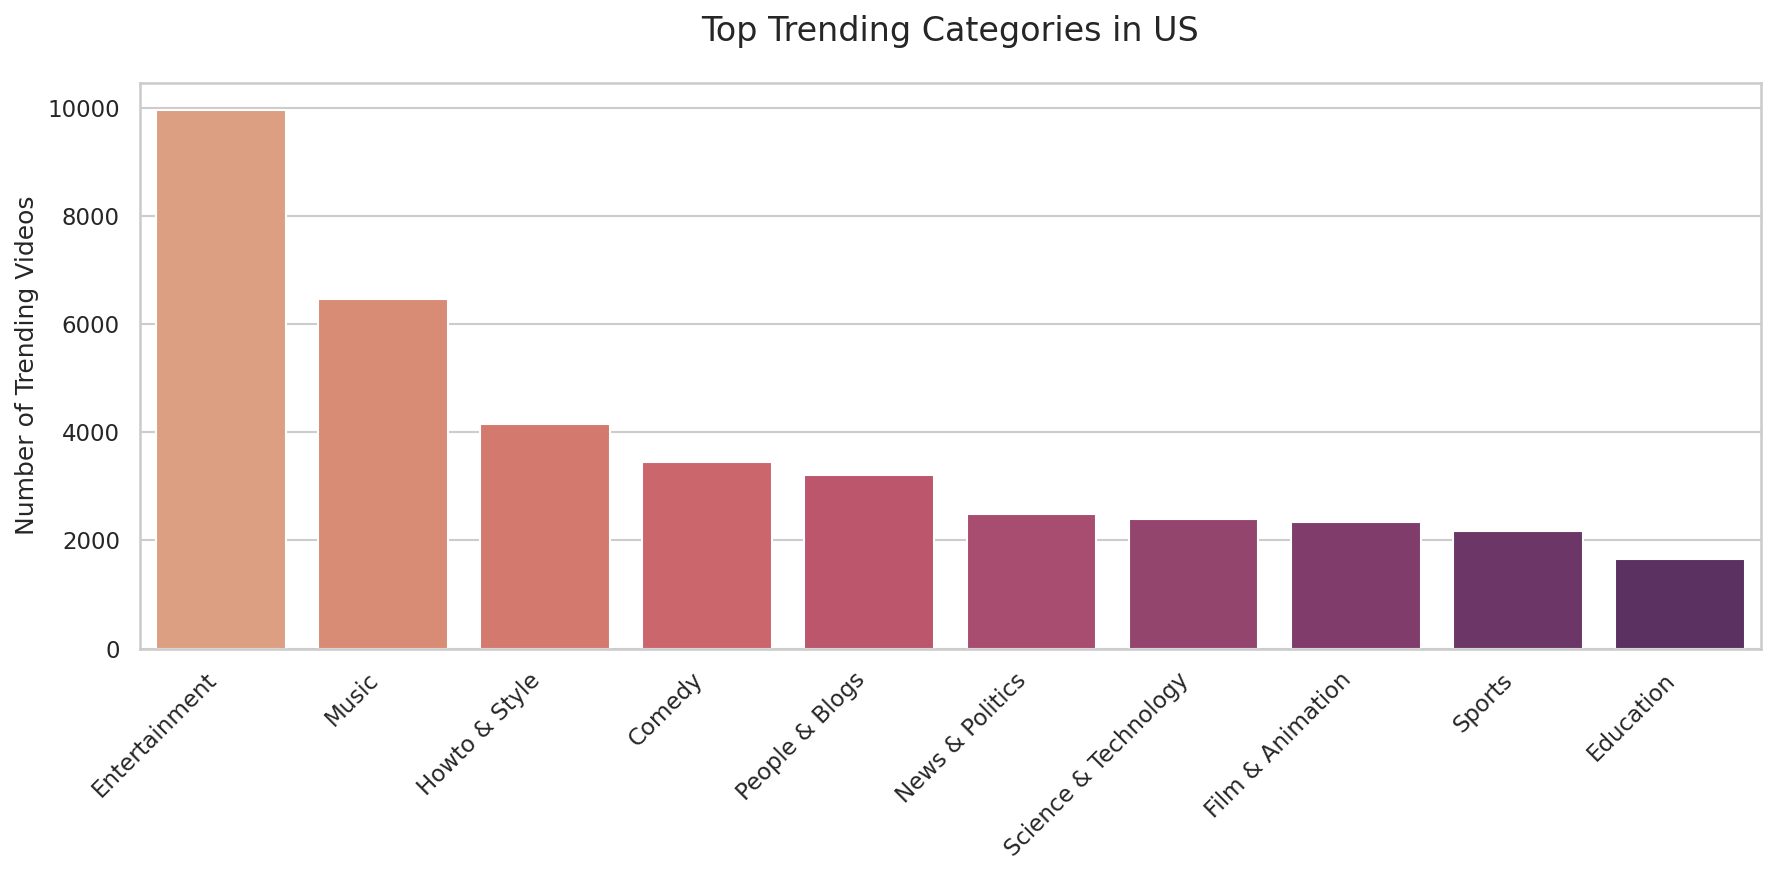

In [9]:
category_counts = us_df['category'].value_counts().head(10)

fig = plt.figure()
sns.barplot(x=category_counts.index, y=category_counts.values, palette='flare')
plt.title("Top Trending Categories in US", pad=20, size=16)
plt.ylabel("Number of Trending Videos")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

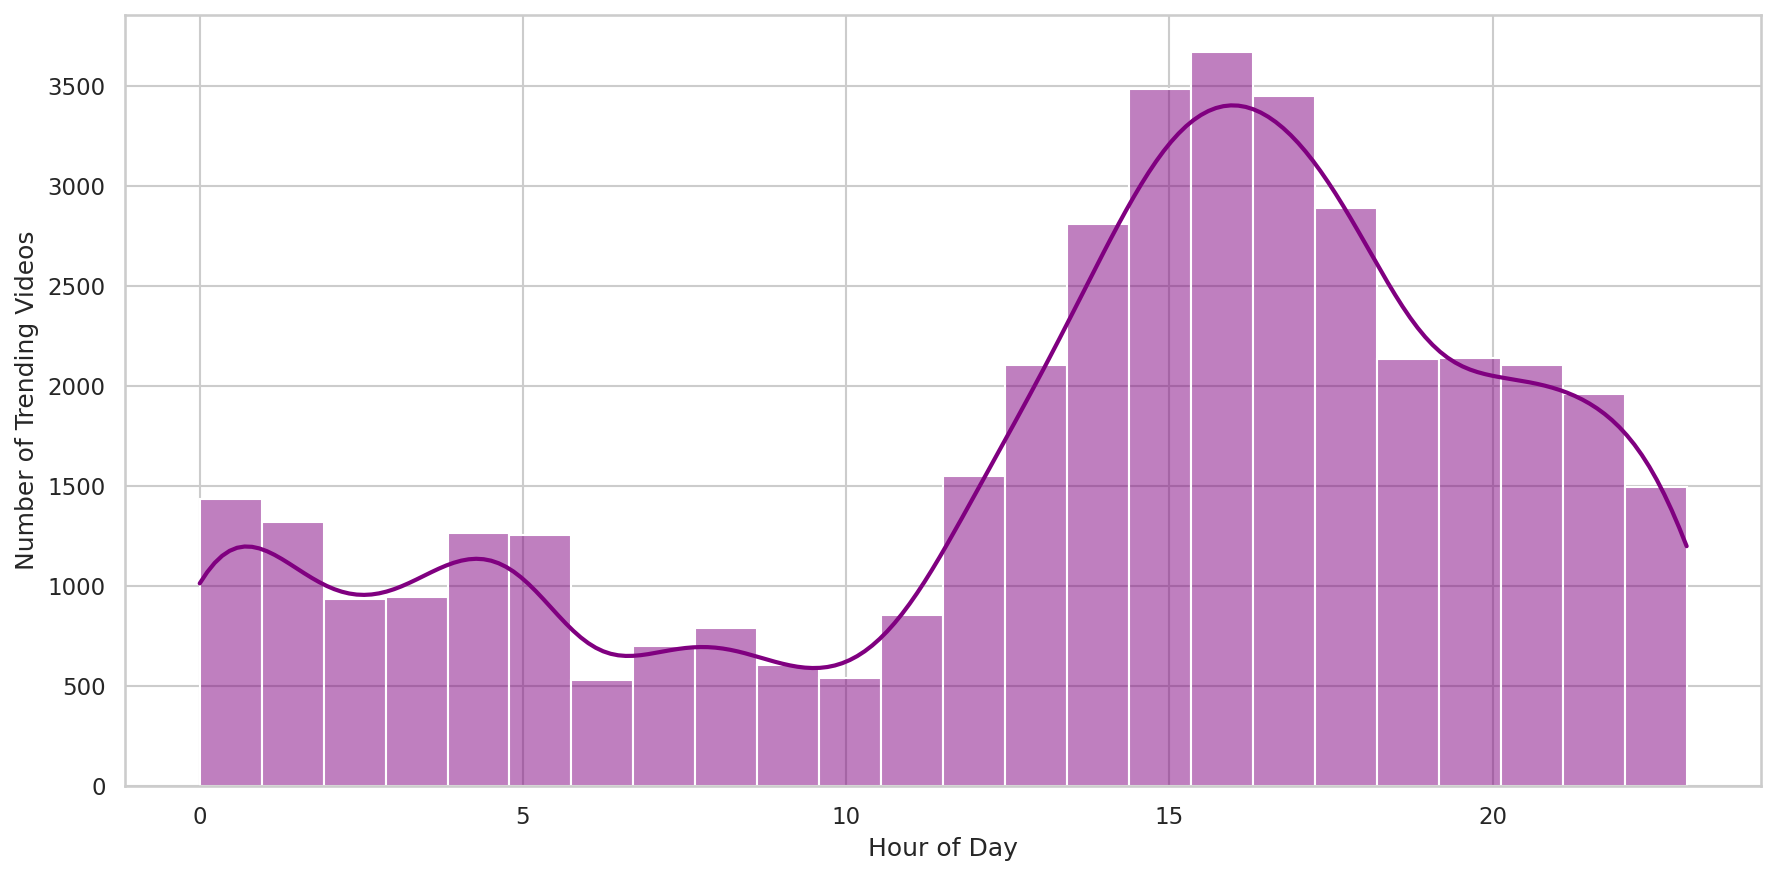

In [10]:
fig = plt.figure()

sns.histplot(us_df['publish_hour'], bins=24, kde=True, color='purple')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trending Videos")

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

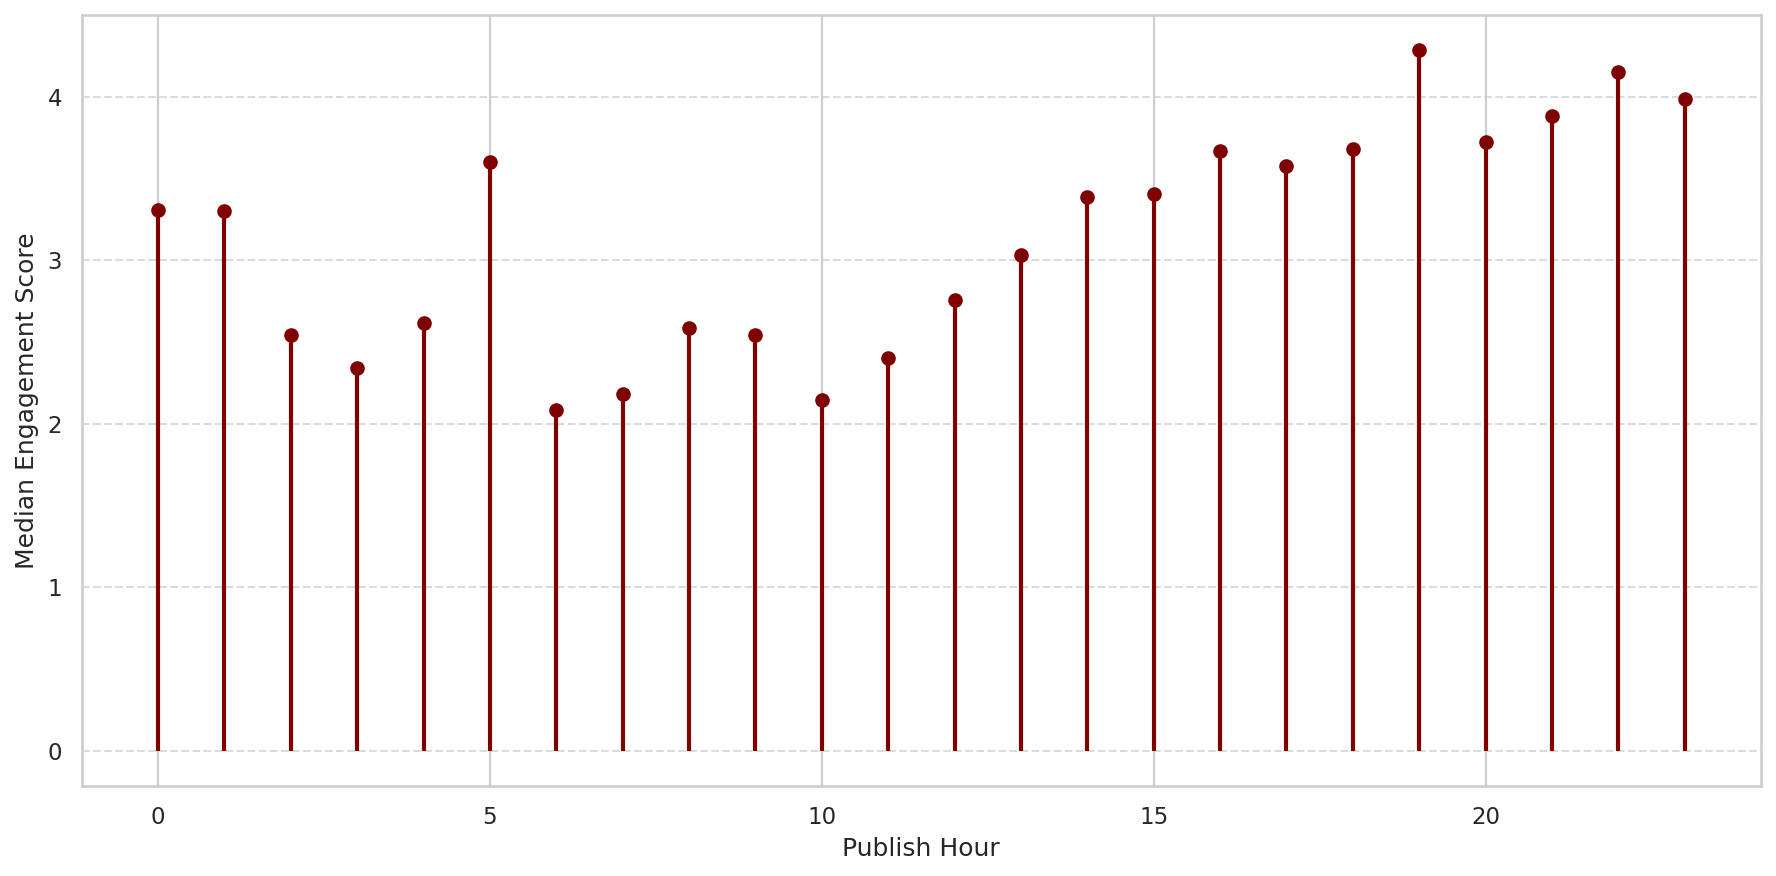

In [11]:
engagement_by_hour = us_df.groupby('publish_hour')['engagement_score'].median().reset_index()

fig = plt.figure()

plt.stem(
    engagement_by_hour['publish_hour'],
    engagement_by_hour['engagement_score'],
    basefmt=" ",
    linefmt="maroon",
    markerfmt="o"
)
plt.xlabel("Publish Hour")
plt.ylabel("Median Engagement Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

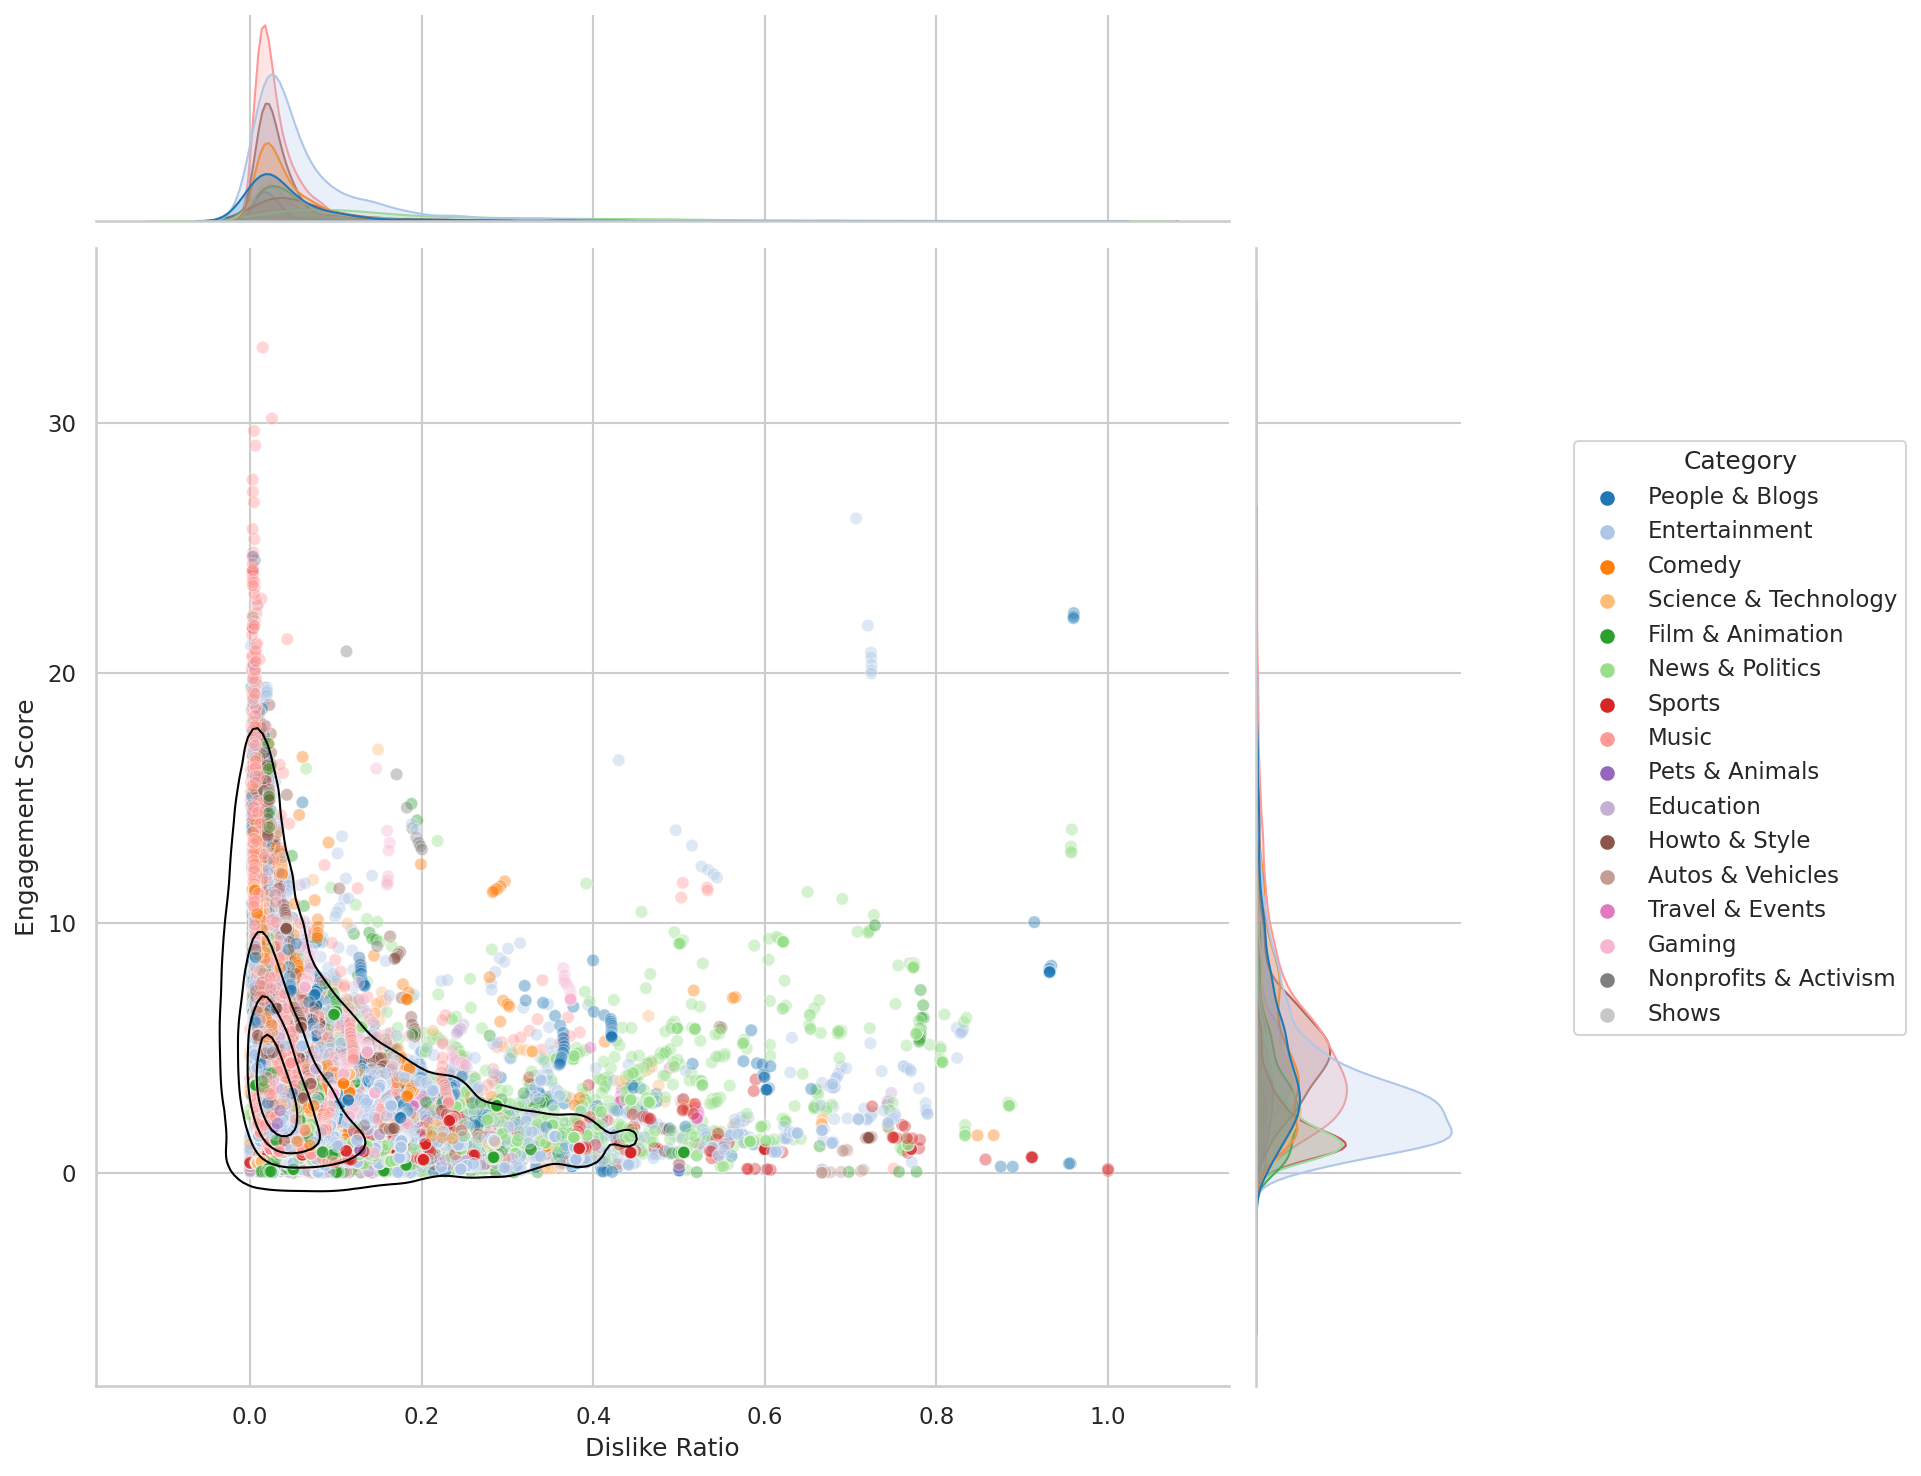

In [12]:
g = sns.jointplot(
    data=us_df,
    x='dislike_ratio',
    y='engagement_score',
    kind='scatter',
    hue='category',
    alpha=0.4,
    palette='tab20',
    marginal_kws=dict(fill=True),
    height=10,
    space=0.2
)

sns.kdeplot(
    data=us_df,
    x='dislike_ratio',
    y='engagement_score',
    ax=g.ax_joint,
    levels=5,
    color='black',
    linewidths=1
)

g.figure.subplots_adjust(top=0.95)

g.ax_joint.set_xlabel("Dislike Ratio")
g.ax_joint.set_ylabel("Engagement Score")

g.figure.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Category")

g.ax_joint.legend_.remove()

fig_recorder.add(g.figure)

g.figure.tight_layout()
g.figure.show()

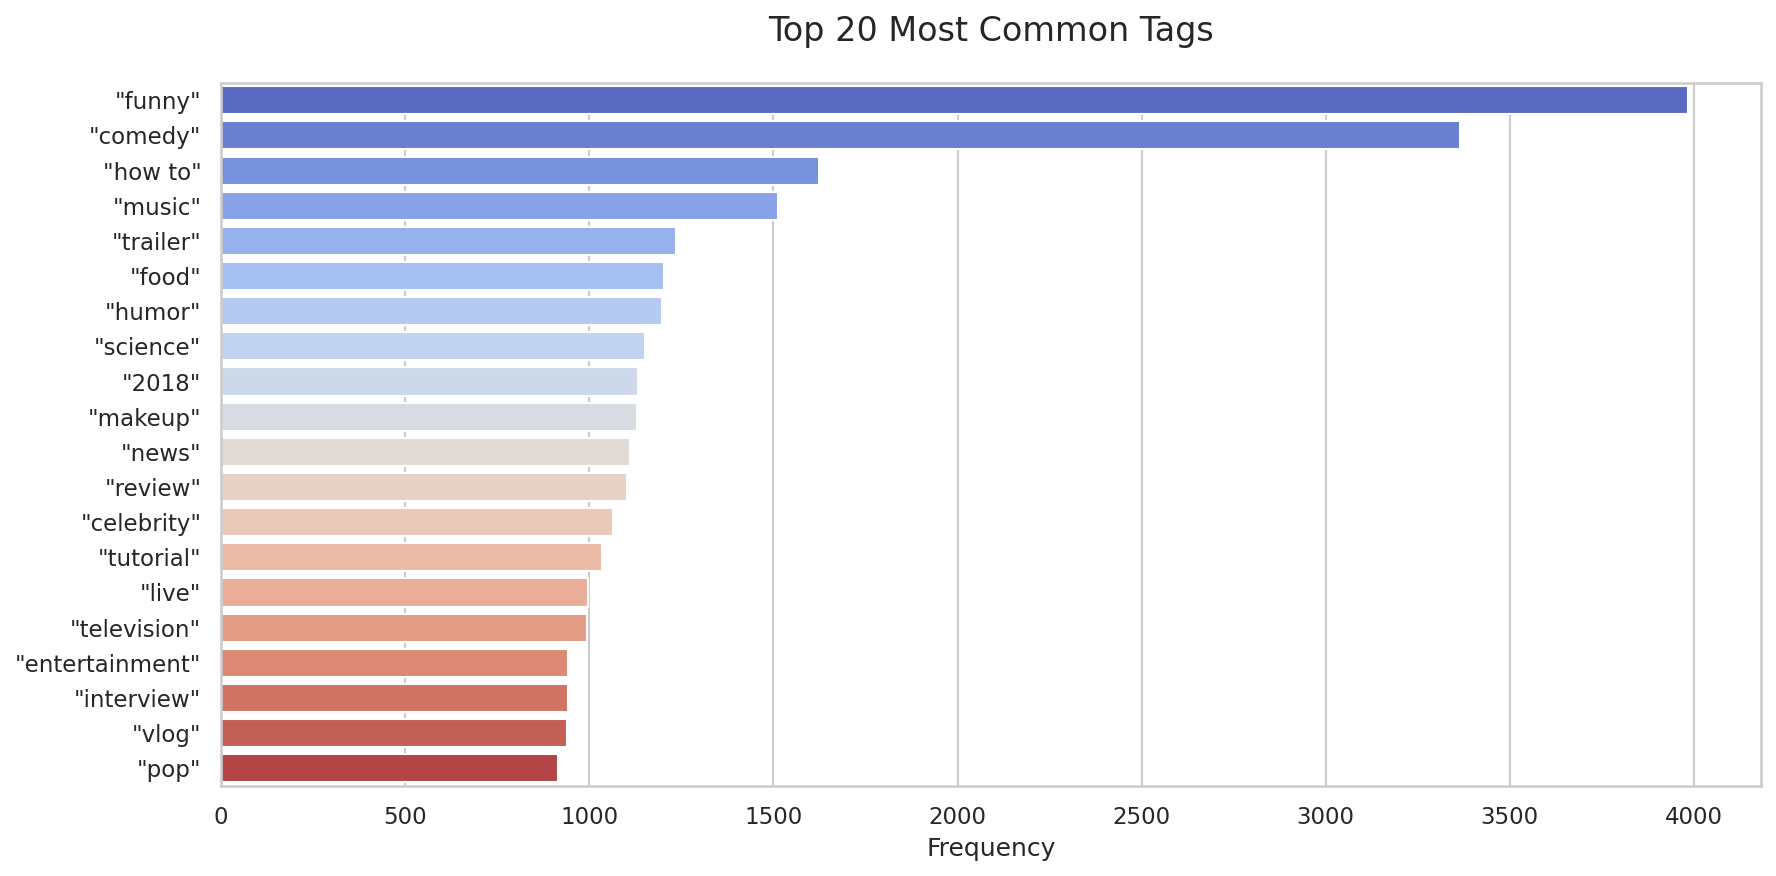

In [13]:
all_tags = ','.join(us_df['tags'].dropna().str.lower()).split('|')
tag_counts = Counter(all_tags)
common_tags = pd.DataFrame(tag_counts.most_common(20), columns=['Tag', 'Frequency'])

fig = plt.figure()

sns.barplot(data=common_tags, x='Frequency', y='Tag', palette='coolwarm')
plt.title("Top 20 Most Common Tags", size=16, pad=20)
plt.ylabel("")

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

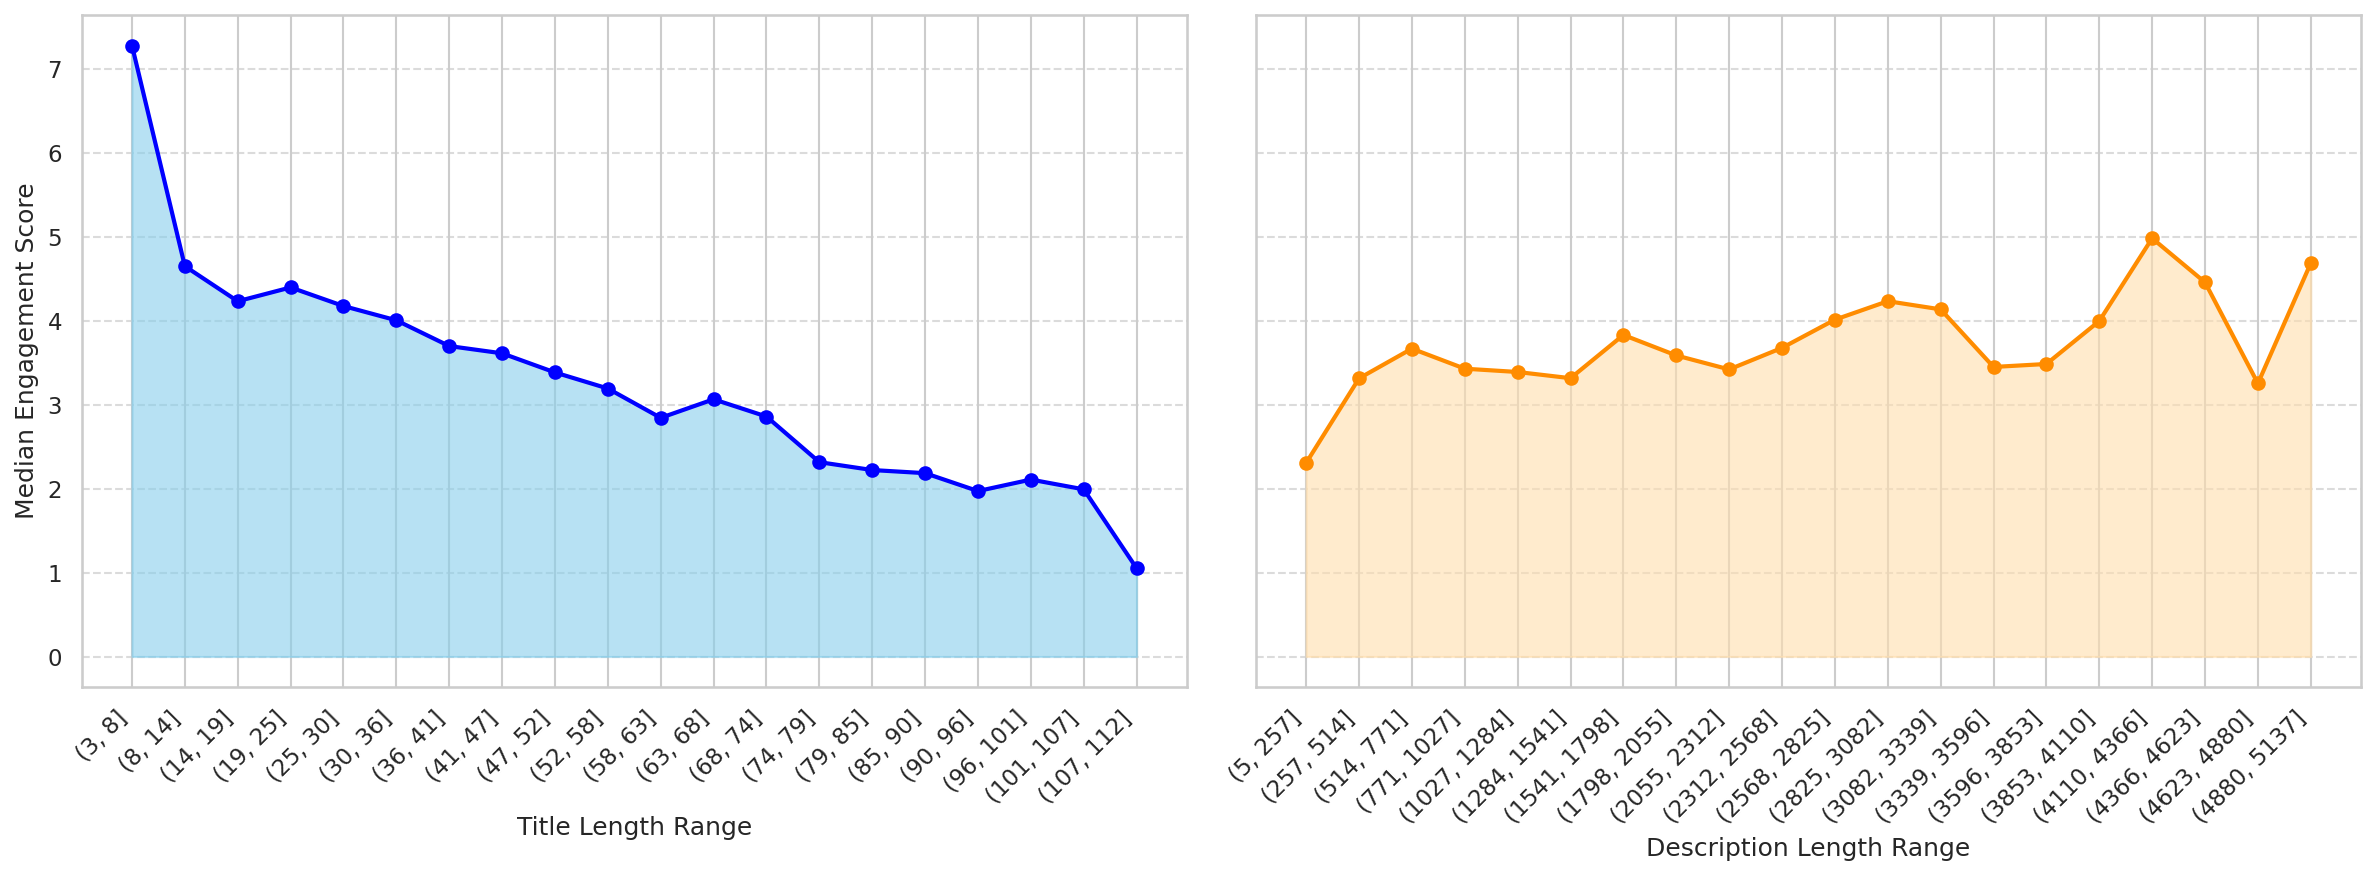

In [14]:
def format_interval(interval):
    return f"({round(abs(interval.left))}, {round(interval.right)}]"

fig, axes = plt.subplots(1, 2, figsize=(16, 6),sharey=True)

filtered_df = us_df[us_df['title_length'] <= 120]

title_bins = pd.cut(filtered_df['title_length'], bins=20)
desc_bins = pd.cut(us_df['description_length'], bins=20)

title_area_data = filtered_df.groupby(title_bins, observed=False)['engagement_score'].median().reset_index()
title_area_data['title_length_bin'] = title_area_data['title_length'].apply(format_interval)

desc_area_data = filtered_df.groupby(desc_bins, observed=False)['engagement_score'].median().reset_index()
desc_area_data['description_length_bin'] = desc_area_data['description_length'].apply(format_interval)

axes[0].fill_between(title_area_data['title_length_bin'], title_area_data['engagement_score'], color='skyblue', alpha=0.6)
axes[0].plot(title_area_data['title_length_bin'], title_area_data['engagement_score'], color='blue', marker='o')
axes[0].set_xticks(range(len(title_area_data)))
axes[0].set_xticklabels(title_area_data['title_length_bin'], rotation=45, ha='right')
axes[0].set_xlabel("Title Length Range")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].fill_between(desc_area_data['description_length_bin'], desc_area_data['engagement_score'], color='navajowhite', alpha=0.6)
axes[1].plot(desc_area_data['description_length_bin'], desc_area_data['engagement_score'], color='darkorange', marker='o')
axes[1].set_xticks(range(len(desc_area_data)))
axes[1].set_xticklabels(desc_area_data['description_length_bin'], rotation=45, ha='right')
axes[1].set_xlabel("Description Length Range")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

axes[0].set_ylabel("Median Engagement Score")

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

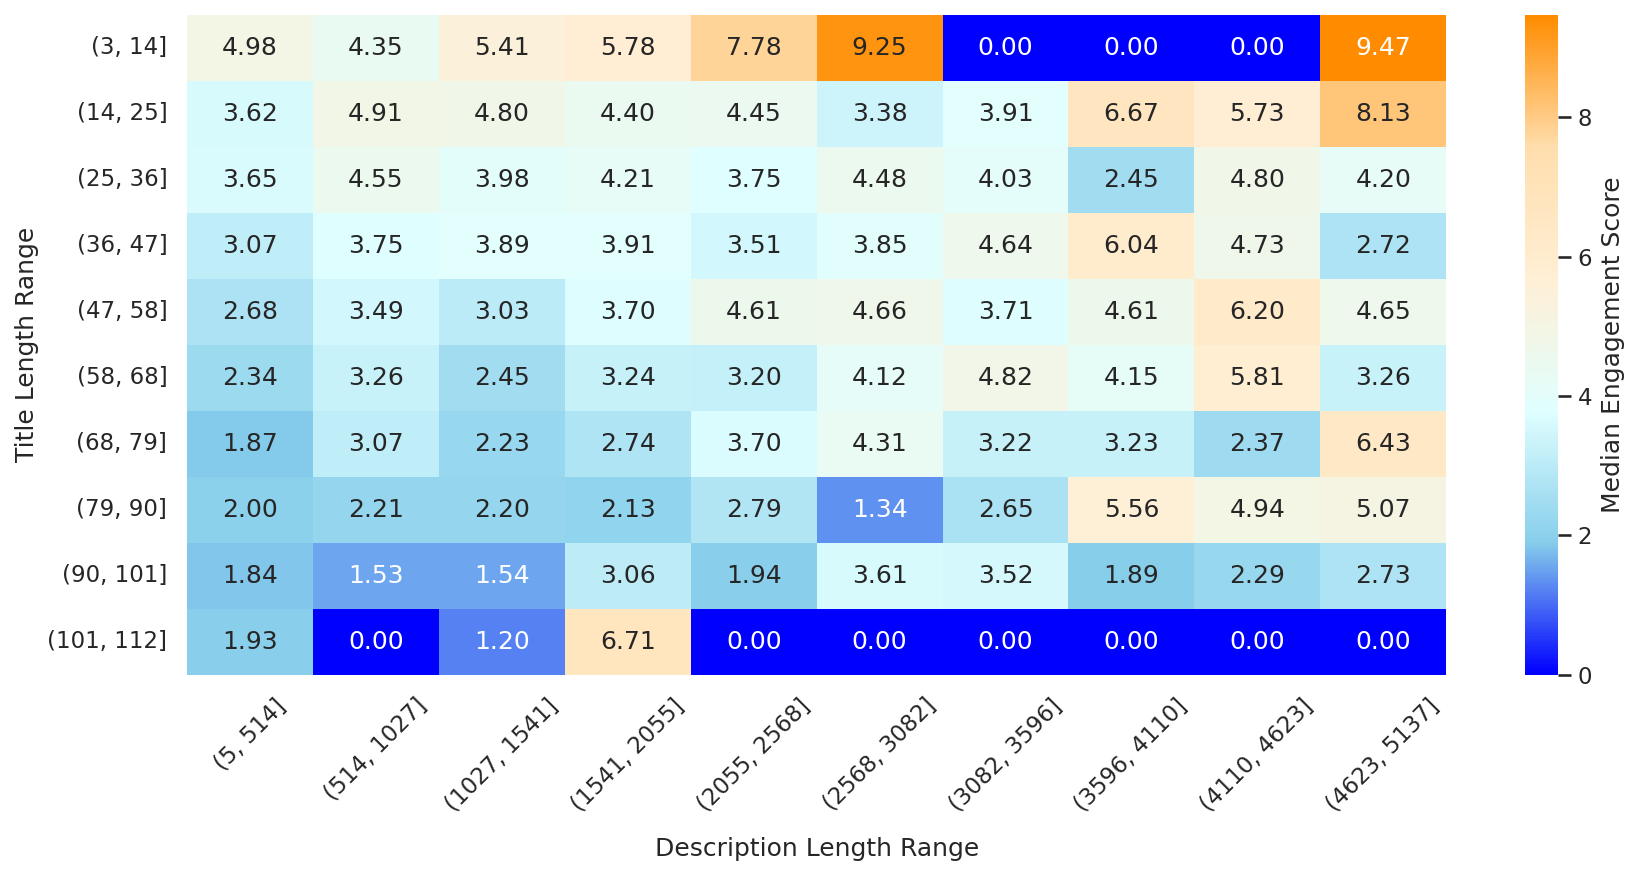

In [15]:
filtered_df = us_df[us_df['title_length'] <= 120].copy()

filtered_df['title_bin'] = pd.cut(filtered_df['title_length'], bins=10)
filtered_df['desc_bin'] = pd.cut(filtered_df['description_length'], bins=10)

grouped = filtered_df.groupby(['title_bin', 'desc_bin'], observed=False)['engagement_score'].median().unstack()

grouped = grouped.fillna(0)

grouped.columns = [format_interval(col) for col in grouped.columns]
grouped.index = [format_interval(idx) for idx in grouped.index]

fig = plt.figure()

sns.heatmap(grouped, annot=True, cmap=freezingflame, fmt=".2f", cbar_kws={'label': 'Median Engagement Score'})

plt.title("")
plt.xlabel("Description Length Range", labelpad=10)
plt.ylabel("Title Length Range")
plt.xticks(rotation=45)

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

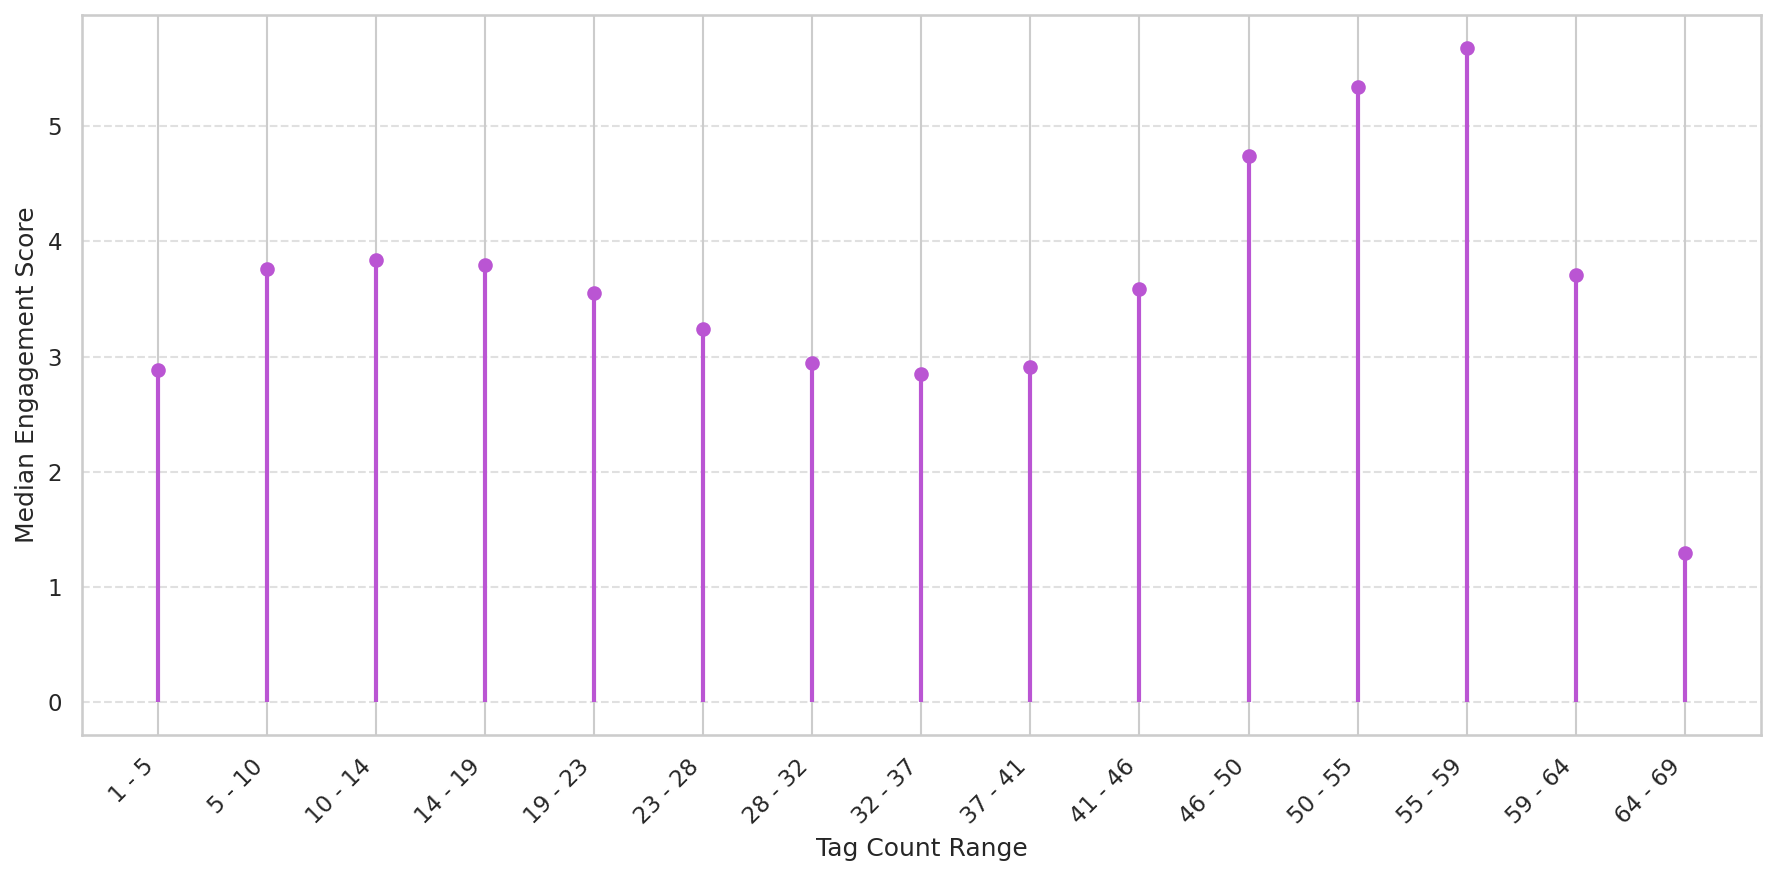

In [16]:
data_filtered = us_df.dropna(subset=['tag_count', 'engagement_score'])
bins = np.linspace(data_filtered['tag_count'].min(), data_filtered['tag_count'].max(), 16)
bin_labels = [f"{int(bins[i])} - {int(bins[i+1])}" for i in range(15)]
data_filtered['tag_count_bin'] = pd.cut(data_filtered['tag_count'], bins=bins, labels=bin_labels, include_lowest=True)

median_scores = data_filtered.groupby('tag_count_bin', observed=True)['engagement_score'].median().reset_index()

fig = plt.figure()

plt.stem(
    median_scores['tag_count_bin'],
    median_scores['engagement_score'],
    basefmt=" ",
    linefmt="mediumorchid",
    markerfmt="o"
)
plt.title("")
plt.xlabel("Tag Count Range")
plt.ylabel("Median Engagement Score")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

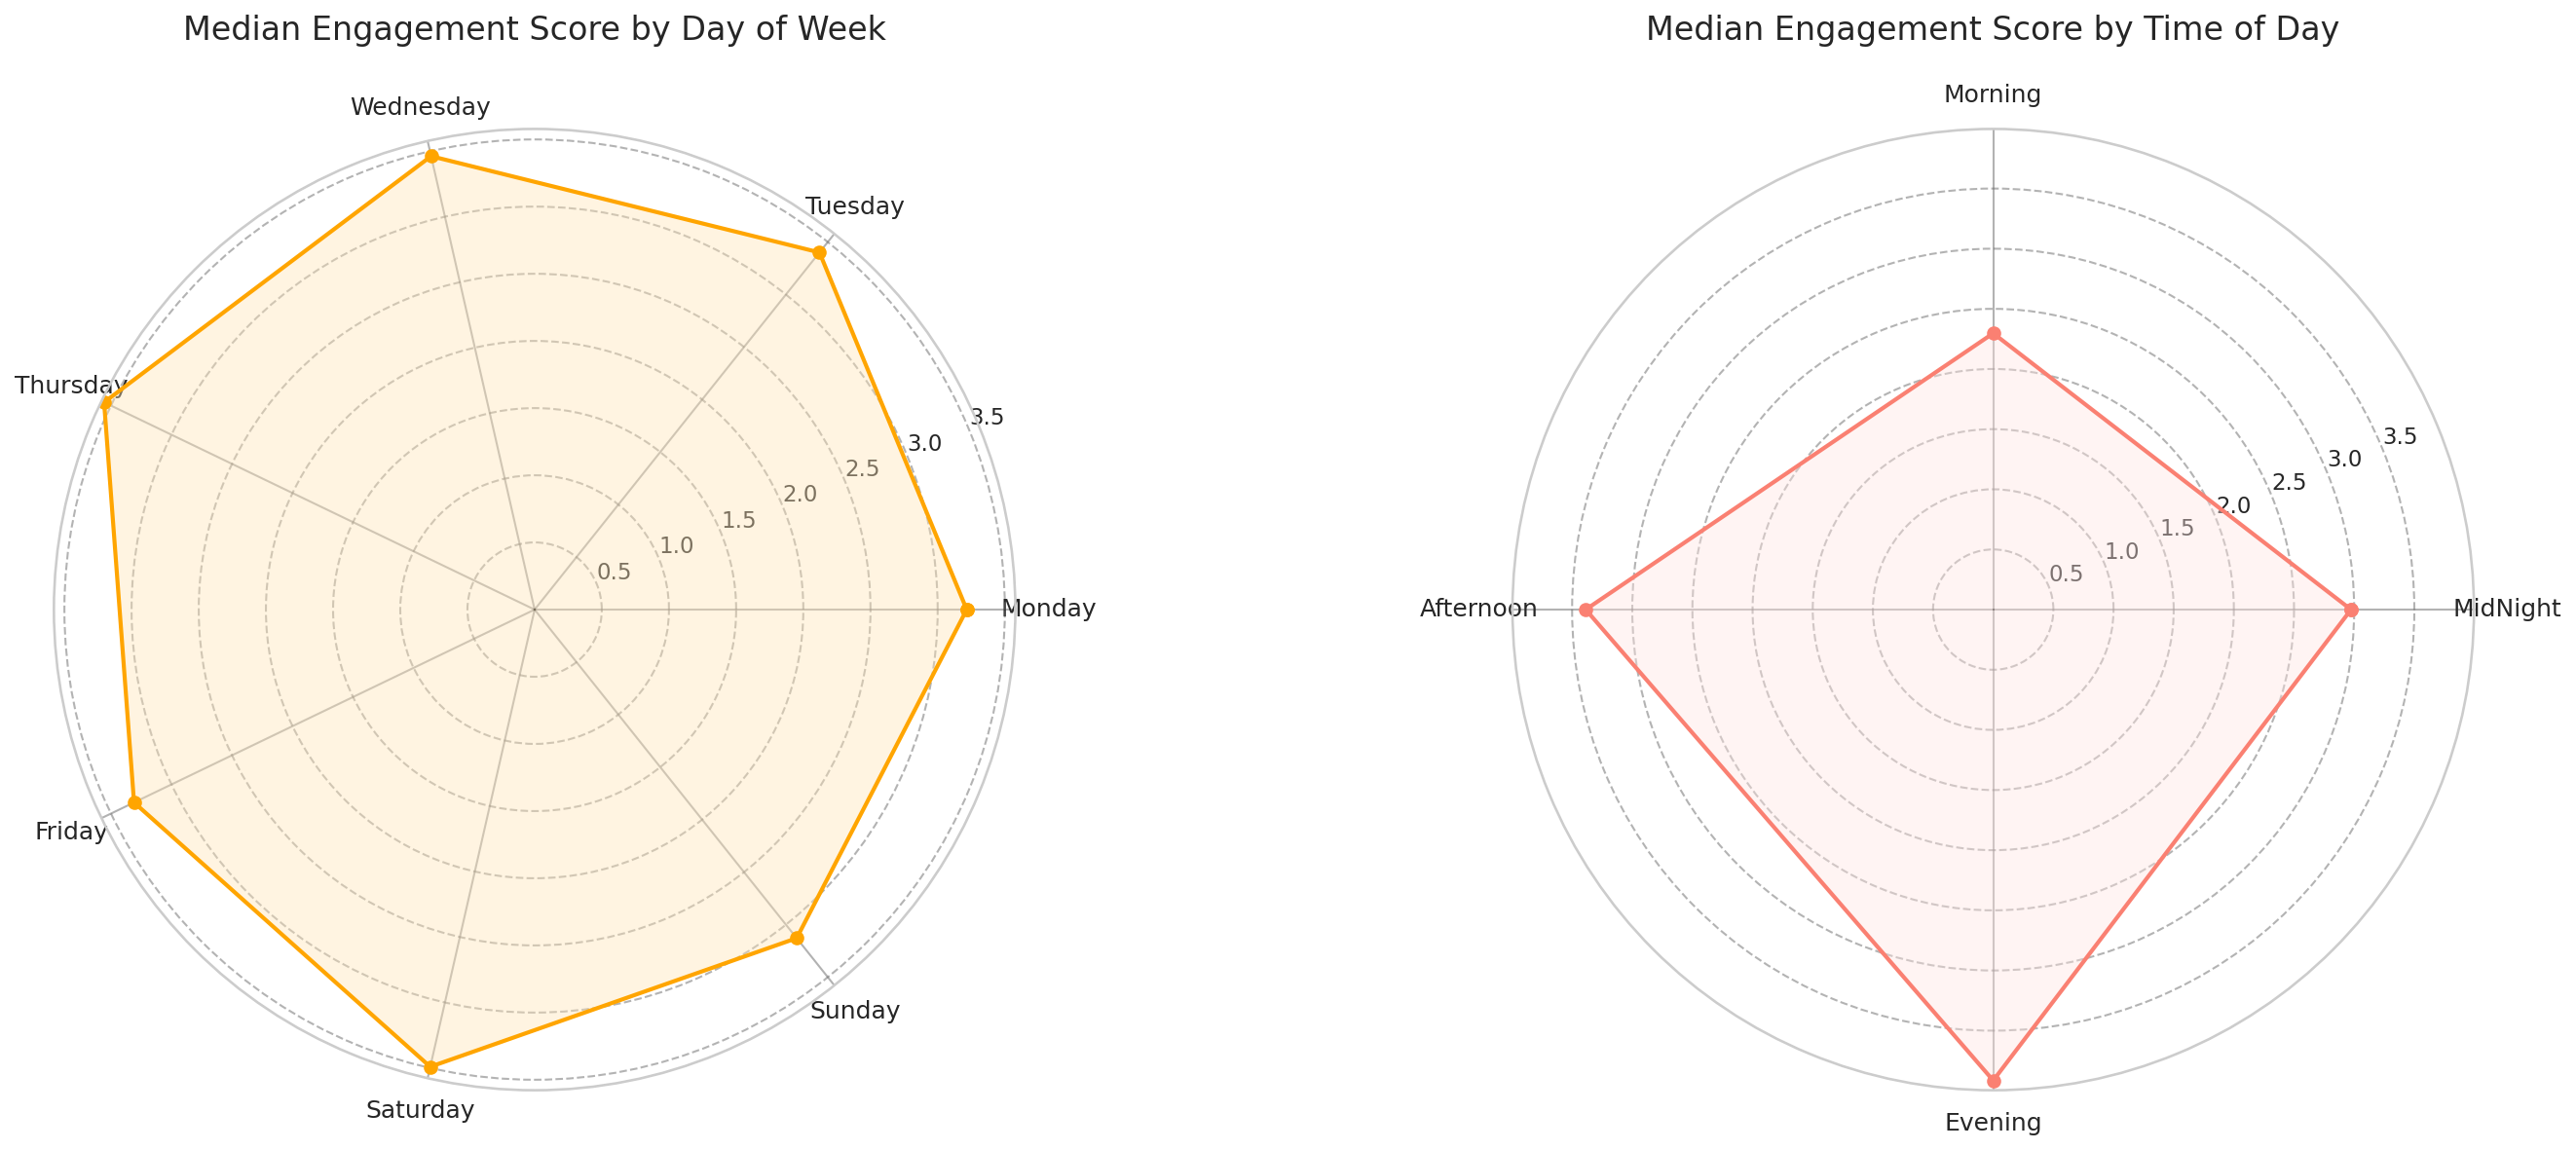

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), subplot_kw=dict(polar=True))

median_engagement_by_day = us_df.groupby('publish_day', observed=True)['engagement_score'].median().reindex(days)

labels = median_engagement_by_day.index.tolist()
stats = median_engagement_by_day.values.tolist()

stats += stats[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

axes[0].plot(angles, stats, color='orange', linewidth=2, marker='o')
axes[0].fill(angles, stats, color='moccasin', alpha=0.4)

axes[0].set_xticks(angles[:-1])
axes[0].set_xticklabels(labels, fontsize=12)

axes[0].set_title("Median Engagement Score by Day of Week", size=16, y=1.08)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5, color="dimgray")
axes[0].xaxis.grid(True, linestyle='solid', alpha=0.3, color='black')


medians = us_df.groupby('time_of_day', observed=True)['engagement_score'].median().reindex(daily_quarters)

labels = medians.index.tolist()
stats = medians.values.tolist()

stats += stats[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

axes[1].plot(angles, stats, color='salmon', linewidth=2, marker='o')
axes[1].fill(angles, stats, color='mistyrose', alpha=0.4)

axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(labels, fontsize=12)

axes[1].set_title("Median Engagement Score by Time of Day", size=16, y=1.08)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5, color="dimgray")
axes[1].xaxis.grid(True, linestyle='solid', alpha=0.3, color='black')

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

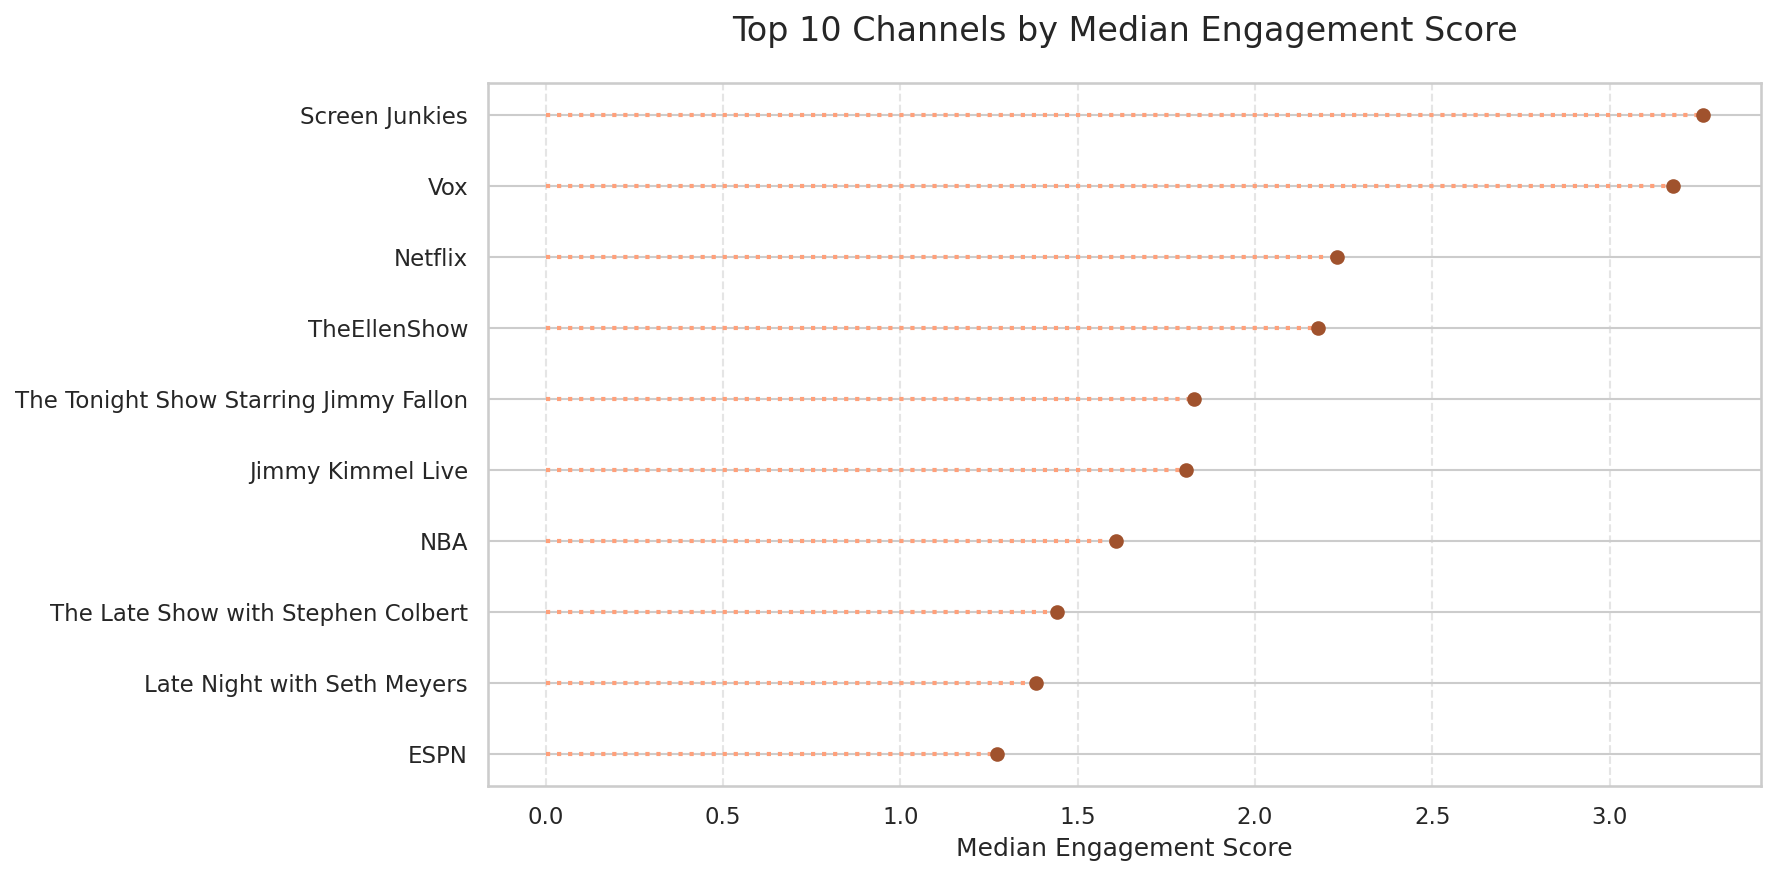

In [18]:
top_channels = us_df['channel_title'].value_counts().head(10).index
top_channels_df = us_df[us_df['channel_title'].isin(top_channels)]

engagement_by_channel = (
    top_channels_df.groupby('channel_title')['engagement_score']
    .median()
    .sort_values(ascending=True)
    .reset_index()
)

fig = plt.figure()

plt.hlines(y=engagement_by_channel['channel_title'], xmin=0,
           xmax=engagement_by_channel['engagement_score'], color='lightsalmon', linestyles="dotted")
plt.plot(engagement_by_channel['engagement_score'], 
         engagement_by_channel['channel_title'], 'o', color='sienna')

plt.title("Top 10 Channels by Median Engagement Score", size=16, pad=20)
plt.xlabel("Median Engagement Score")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

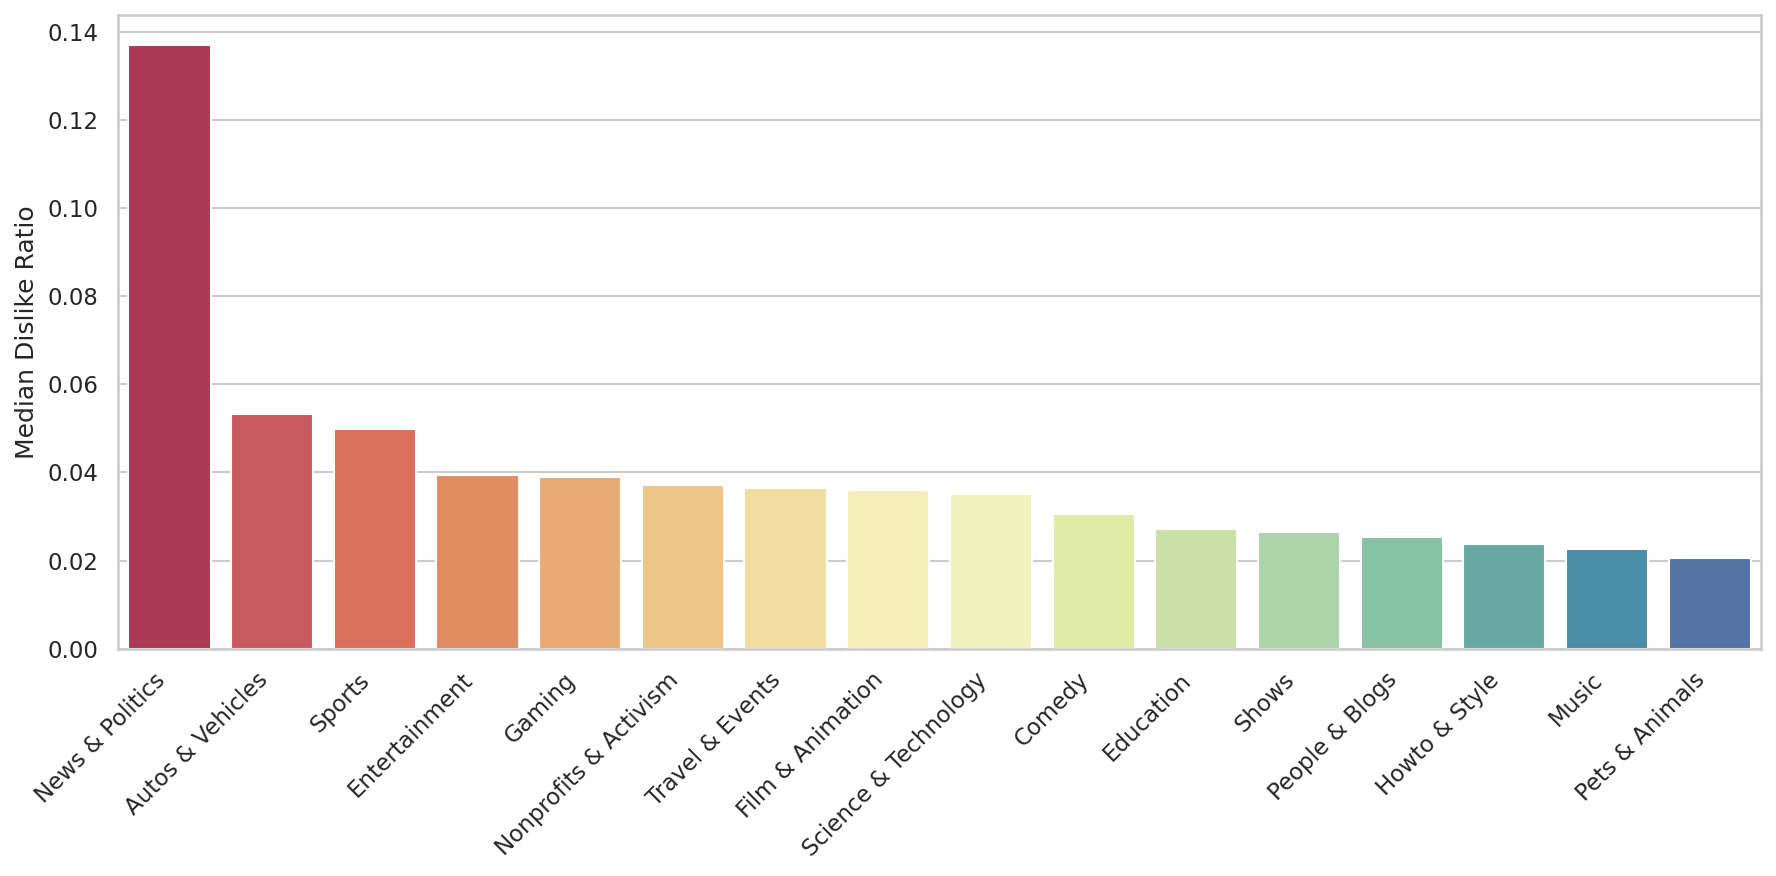

In [19]:
avg_dislike_by_cat = us_df.groupby('category')['dislike_ratio'].median().sort_values(ascending=False)

fig = plt.figure()

sns.barplot(x=avg_dislike_by_cat.index, y=avg_dislike_by_cat.values, palette='Spectral')
plt.title("")
plt.ylabel("Median Dislike Ratio")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

# Predicting Engagement Score with XGBoost

An XGBoost regression model is employed to predict the **engagement score** of trending YouTube videos based on various metadata features.

#### Preprocessing Steps:
- **Categorical Encoding**:
  Label encoding is applied to transform categorical features into numerical format:
  - `category` → `category_encoded`  
  - `publish_day` → `publish_day_encoded`  
  - `time_of_day` → `time_of_day_encoded`
  
- **Feature Selection**:  
  The following features are selected for modeling:
  - Content-based: `title_length`, `description_length`, `tag_count`
  - Temporal: `publish_day_encoded`, `publish_hour`, `time_of_day_encoded`
  - Category: `category_encoded`

- Rows with missing values in any selected feature or the target variable (`engagement_score`) are removed to ensure model integrity.

#### Model Training:
- The dataset is split into training and test sets (80/20 split).
- An XGBoost regressor is initialized with 100 estimators and trained on the training data.
- Performance metrics are computed:
  - **RMSE (Root Mean Squared Error)** evaluates prediction accuracy.
  - **R² Score** measures how well the variance in engagement is explained by the model.

#### Feature Importance:
- Feature importances are extracted from the trained model and visualized in a horizontal lolipop plot.
- This visualization highlights which attributes most strongly influence video engagement, providing actionable insights for content strategy and platform optimization.

In [20]:
le_category = LabelEncoder()
us_df['category_encoded'] = le_category.fit_transform(us_df['category'].astype(str))
le_day = LabelEncoder()
us_df['publish_day_encoded'] = le_day.fit_transform(us_df['publish_day'].astype(str))
le_time = LabelEncoder()
us_df['time_of_day_encoded'] = le_time.fit_transform(us_df['time_of_day'].astype(str))

features = [
    'title_length', 'description_length', 'tag_count',
    'category_encoded', 'publish_day_encoded', 'publish_hour', 'time_of_day_encoded'
]
target = 'engagement_score'

model_df = us_df[features + [target]].dropna()

X_train, X_test, y_train, y_test = train_test_split(
    model_df[features], model_df[target], test_size=0.2, random_state=42
)

In [21]:
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xg_reg.fit(X_train, y_train)

y_pred = xg_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost RMSE: {rmse:.4f}")
print(f"XGBoost R-Squared Score: {r2:.4f}")

XGBoost RMSE: 1.7257
XGBoost R-Squared Score: 0.6792


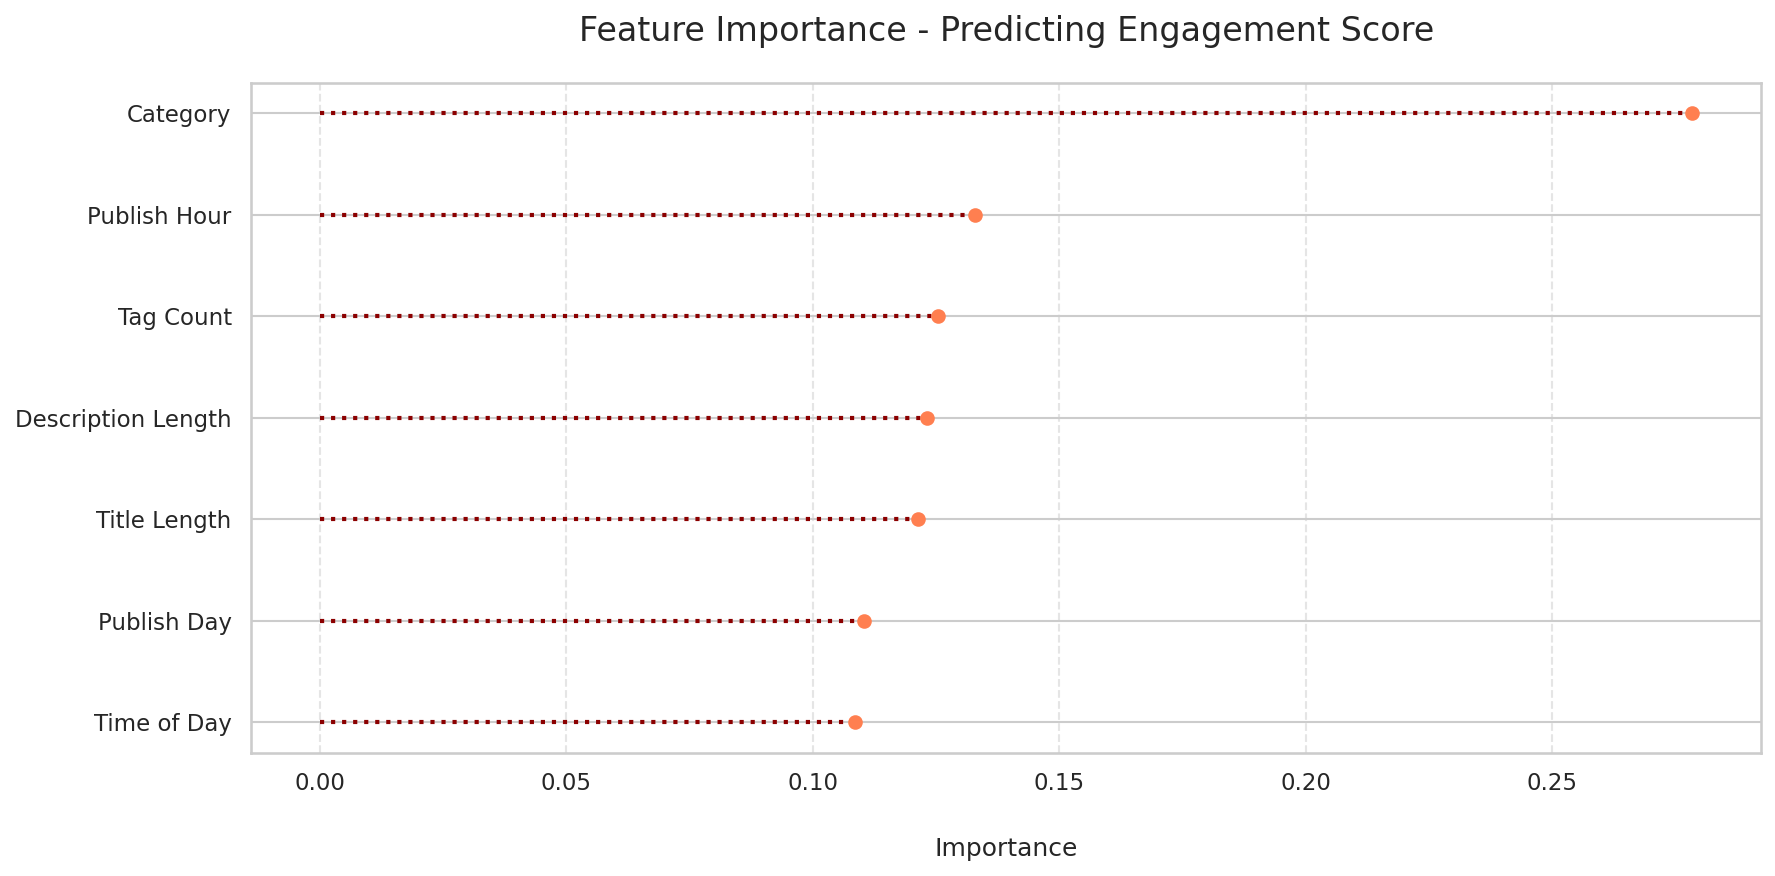

In [22]:
feature_importances = pd.Series(xg_reg.feature_importances_, index=features)
sorted_importances = feature_importances.sort_values(ascending=True)

label_map = {
    'category_encoded': 'Category',
    'publish_day_encoded': 'Publish Day',
    'time_of_day_encoded': 'Time of Day',
    'title_length': 'Title Length',
    'description_length': 'Description Length',
    'tag_count': 'Tag Count',
    'publish_hour': 'Publish Hour'
}

mapped_labels = [label_map.get(feat, feat) for feat in sorted_importances.index]

fig = plt.figure()
plt.hlines(y=mapped_labels, xmin=0, xmax=sorted_importances.values, color='darkred', linestyles='dotted')
plt.plot(sorted_importances.values, mapped_labels, "o", color='coral')

plt.title("Feature Importance - Predicting Engagement Score", size=16, pad=20)
plt.xlabel("Importance", labelpad=20)
plt.grid(axis='x', linestyle='--', alpha=0.5)

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

# Sentiment Analysis of Video Descriptions and Engagement

#### Sentiment Computation:
- Missing descriptions are filled with empty strings to ensure compatibility with text processing.
- **TextBlob** is used to compute a **sentiment polarity score** for each description, ranging from -1 (very negative) to +1 (very positive).

#### Sentiment vs. Engagement – Hexbin Plot:
- A **hexbin plot** is created to visualize the joint distribution of sentiment polarity and engagement score.
- A logarithmic color scale is applied to indicate point density, helping to reveal concentration trends.

#### Sentiment Categorization:
- Sentiment polarity scores are binned into three categories:
  - **Negative**: Polarity < -0.1
  - **Neutral**: -0.1 ≤ Polarity ≤ 0.1
  - **Positive**: Polarity > 0.1
- The `sentiment_bin` column is converted to an ordered categorical type for consistent visualization.

#### Engagement Distribution – Violin Plot:
- A **violin plot** is used to display the distribution of engagement scores across the three sentiment categories.
- The plot includes quartile indicators and is constrained to the actual data range for clarity.

#### Statistical Testing:
- A **Kruskal-Wallis H test** (non-parametric ANOVA) is performed to determine whether significant differences exist in engagement scores among sentiment groups.
  - The test statistic and p-value are reported.
  - A result is considered significant if *p < 0.05*.

#### Median Engagement by Sentiment:
- Median engagement scores are computed for each sentiment category.
- A bar chart is plotted to visualize how median engagement varies with sentiment polarity.

In [23]:
us_df['description'] = us_df['description'].fillna('')
us_df['sentiment'] = us_df['description'].apply(lambda text: TextBlob(text).sentiment.polarity)

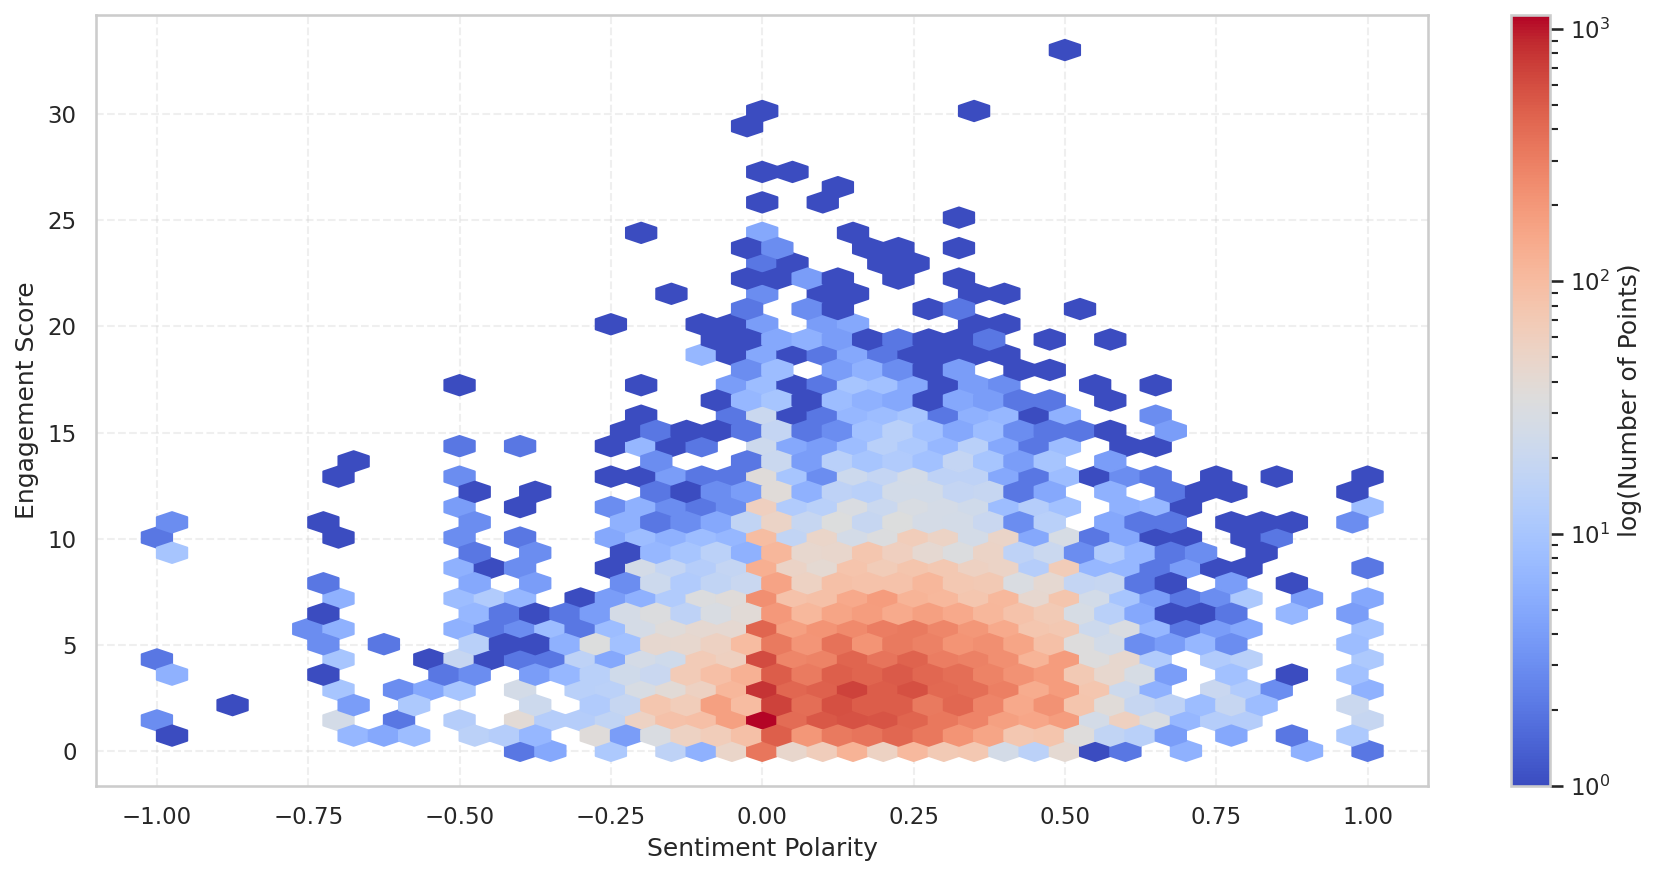

In [24]:
fig = plt.figure()

plt.hexbin(
    us_df['sentiment'],
    us_df['engagement_score'],
    gridsize=40,
    cmap='coolwarm',
    bins='log'
)
plt.colorbar(label='log(Number of Points)')
plt.title("")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Engagement Score")
plt.grid(True, linestyle='--', alpha=0.3)

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

In [25]:
def categorize_sentiment(polarity):
    if polarity < -0.1:
        return 'Negative'
    elif polarity > 0.1:
        return 'Positive'
    else:
        return 'Neutral'
        
us_df['sentiment_bin'] = us_df['sentiment'].apply(categorize_sentiment)

us_df['sentiment_bin'] = pd.Categorical(us_df['sentiment_bin'], categories=['Negative', 'Neutral', 'Positive'], ordered=True)

negative_scores = us_df[us_df['sentiment_bin'] == 'Negative']['engagement_score'].dropna()
neutral_scores = us_df[us_df['sentiment_bin'] == 'Neutral']['engagement_score'].dropna()
positive_scores = us_df[us_df['sentiment_bin'] == 'Positive']['engagement_score'].dropna()

stat, p_value = kruskal(negative_scores, neutral_scores, positive_scores)

print("Kruskal-Wallis H Test:")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ There is a statistically significant difference in engagement scores across sentiment categories.")
else:
    print("\n❌ No significant difference found in engagement scores across sentiment categories.")

Kruskal-Wallis H Test:
Statistic: 116.5905
p-value: 0.0000

✅ There is a statistically significant difference in engagement scores across sentiment categories.


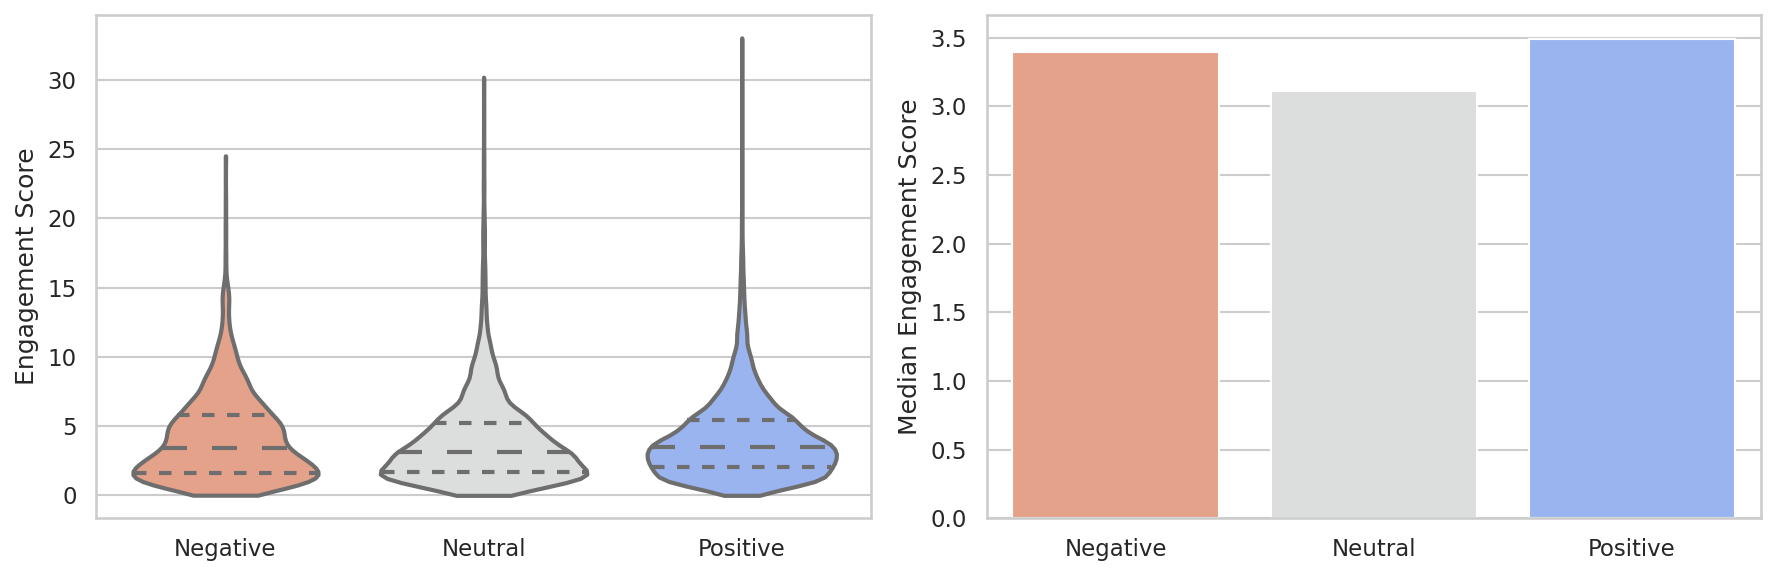

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.violinplot(
    ax=axes[0],
    data=us_df,
    x='sentiment_bin',
    y='engagement_score',
    palette='coolwarm_r',
    inner='quartile',
    cut=0
)
axes[0].set_ylabel("Engagement Score")
axes[0].set_xlabel("")

sentiment_medians = us_df.groupby('sentiment_bin', observed=True)['engagement_score'].median().reindex(['Negative', 'Neutral', 'Positive'])

sns.barplot(ax=axes[1], x=sentiment_medians.index, y=sentiment_medians.values, palette='coolwarm_r')
axes[1].set_ylabel("Median Engagement Score")
axes[1].set_xlabel("")

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

# Clickbait Detection and Its Impact on Engagement

#### Clickbait Identification:
- A curated list of common clickbait phrases (e.g., *“shocking”*, *“you won’t believe”*, *“top 10”*, *“conspiracy”*) is used to scan video titles.
- Titles containing any of these keywords are flagged as **clickbait** using regular expression matching.
- A new boolean column `is_clickbait` is created to reflect this classification.

#### Statistical Analysis:
- The **Mann-Whitney U test** (a non-parametric alternative to the t-test) is performed to compare engagement score distributions between clickbait and non-clickbait titles.
  - The test statistic and p-value are reported.
  - Significance is interpreted based on a 0.05 threshold.

#### Engagement Distribution:
- **Violin plots** and **kernel density estimates (KDE)** are generated to visualize differences in engagement score distributions.
- Central tendencies and spread (median, interquartile range) are calculated for both groups and displayed in a bar chart.

#### Category-Level Insights:
- The proportion of clickbait titles is calculated for each video category.
- A horizontal bar chart is plotted to show which categories are most frequently associated with clickbait strategies.

This analysis provides insight into how emotionally charged or sensational titles may influence viewer interaction, and whether certain content categories are more prone to clickbait tactics.

In [27]:
clickbait_keywords = [
    "shocking", 
    "must watch",
    "unbelievable", 
    "you won't believe", 
    "crazy", 
    "amazing", 
    "epic", 
    "the truth about", 
    "gone wrong", 
    "secret", 
    "exposed",
    "act now", 
    "limited time", 
    "before it's too late", 
    "top 10", 
    "top 5",
    "10 ways to", 
    "5 ways to", 
    "don't make these mistakes", 
    "surprise", 
    "heartbreaking", 
    "thrilling", 
    "twist", 
    "psychology", 
    "they don't want",
    "they won't", 
    "impossible", 
    "we need to", 
    "misconception", 
    "deadliest", 
    "fear", 
    "last to leave", 
    "manhunt", 
    "cover up", 
    "cover-up",
    "unmask", 
    "lied", 
    "this is how", 
    "this happened", 
    "was right about",
    "right about",
    "changes everything", 
    "conspiracy", 
    "controversy", 
    "conspiracies",
    "controversies", 
    "destroys", 
    "this needs to", 
    "hiding", 
    "watch this",
    "how did we", 
    "hidden truth",
    "i can't believe",
    "the real reason",
    "bombshell",
    "this is why",
    "they're not telling",
    "hack",
    "don't trust",
    "humiliated",
    "much worse",
    "insane",
    "spoilers",
]

def is_clickbait(title):
    title_lower = title.lower()
    
    return any(re.search(rf'\b{re.escape(word)}\b', title_lower) for word in clickbait_keywords)

us_df['is_clickbait'] = us_df['title'].apply(is_clickbait)

clickbait_scores = us_df[us_df['is_clickbait']]['engagement_score'].dropna()
non_clickbait_scores = us_df[~us_df['is_clickbait']]['engagement_score'].dropna()

In [28]:
stat, p = mannwhitneyu(clickbait_scores, non_clickbait_scores, alternative='two-sided')

print(f"Mann-Whitney U Test:")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ There is a statistically significant difference in engagement scores between clickbait and non-clickbait titles.")
else:
    print("\n❌ There is no difference in engagement score distributions between clickbait and non-clickbait titles.")

Mann-Whitney U Test:
Statistic: 21830383.0000
p-value: 0.0000

✅ There is a statistically significant difference in engagement scores between clickbait and non-clickbait titles.


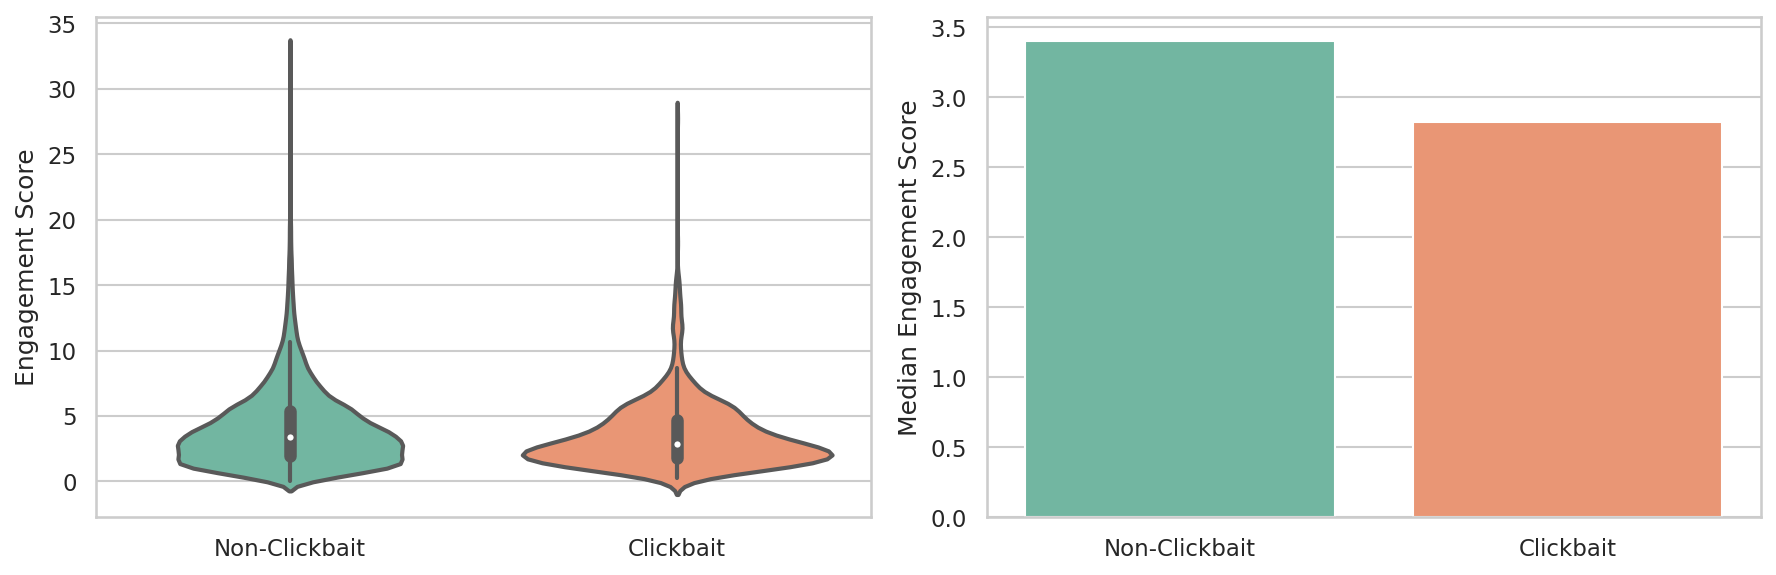

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

engagement_stats = us_df.groupby('is_clickbait')['engagement_score'].agg([
    ('Median', 'median'),
    ('IQR', lambda x: x.quantile(0.75) - x.quantile(0.25))
])

sns.violinplot(ax=axes[0], x='is_clickbait', y='engagement_score', data=us_df, palette='Set2')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Clickbait', 'Clickbait'])
axes[0].set_xlabel("")
axes[0].set_ylabel("Engagement Score")


sentiment_medians = us_df.groupby('is_clickbait', observed=True)['engagement_score'].median()

sns.barplot(ax=axes[1], x=sentiment_medians.index, y=sentiment_medians.values, palette='Set2')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Clickbait', 'Clickbait'])
axes[1].set_ylabel("Median Engagement Score")
axes[1].set_xlabel("")

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

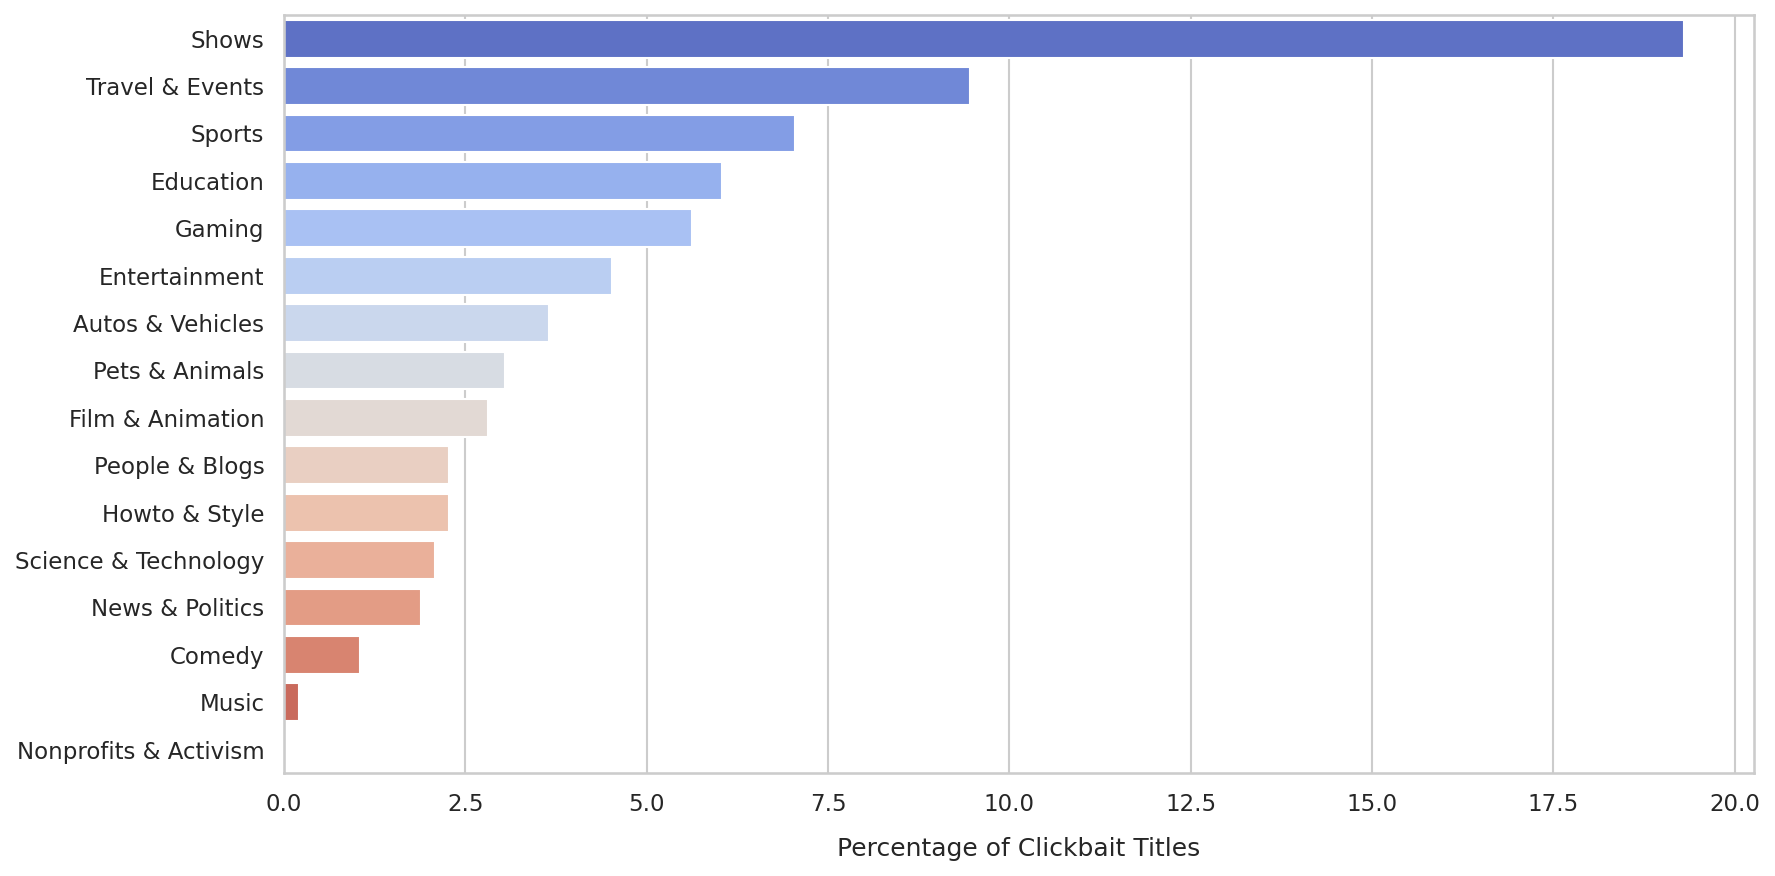

In [30]:
clickbait_by_category = us_df.groupby('category')['is_clickbait'].mean().sort_values(ascending=False) * 100

fig = plt.figure()

sns.barplot(x=clickbait_by_category.values, y=clickbait_by_category.index, palette='coolwarm')
plt.xlabel("Percentage of Clickbait Titles", labelpad=10)
plt.ylabel("")

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

# Statistical Questions

An statistical examination was conducted to answer two questions:
1. **Is there a significant association between the day of the week a video is published and its likelihood of trending?**
2. **Is there a significant difference in viewer engagement (likes-to-views ratio) across different video categories?**
    
#### Chi-Square Goodness-of-Fit Test – Publish Day:
- A **goodness-of-fit test** was applied to compare the observed distribution of trending videos by day of the week against an expected uniform distribution.
- The hypothesis tested whether videos are **equally likely to trend on any day**.
- A **Chi-square statistic** and p-value were computed to assess deviation from uniformity.

#### Radar Plot – Trending Videos by Day:
- A polar (radar) plot was constructed to **visualize the count of trending videos** published on each day of the week.
- The circular layout emphasizes cyclic weekly patterns in publishing and trending behavior.

#### Kruskal-Wallis H Test – Likes/Views Ratio by Category:
- To explore **likes/views ratio variation by content type**, the Kruskal-Wallis H test was applied across all categories with sufficient sample size.
- The test evaluated whether **median likes/views ratios** differed significantly between groups.

#### Lollipop Plot – Median Likes/Liews Ratio by Category:
- Categories were ranked based on their **median likes/views ratio**.
- A **horizontal lollipop plot** highlighted which categories tend to receive higher (or lower) viewer engagement.

This analysis contributes to understanding how publishing behavior and content type may influence both the visibility and success of videos in the trending ecosystem.

In [31]:
day_counts = us_df['publish_day'].value_counts().reindex(days)

expected_counts = [len(us_df) / 7] * 7

chi2, p_val = chisquare(f_obs=day_counts, f_exp=expected_counts)

print("Chi-Square Goodness-of-Fit Test for Trending Videos by Day of Week")
print(f"Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("\n✅ There is a statistically significant association between the day of the week a video is published and its likelihood of trending.")
else:
    print("\n❌ There is no association between the day of publishing and a video's chance of trending.")


Chi-Square Goodness-of-Fit Test for Trending Videos by Day of Week
Statistic: 2420.4288
p-value: 0.0000

✅ There is a statistically significant association between the day of the week a video is published and its likelihood of trending.


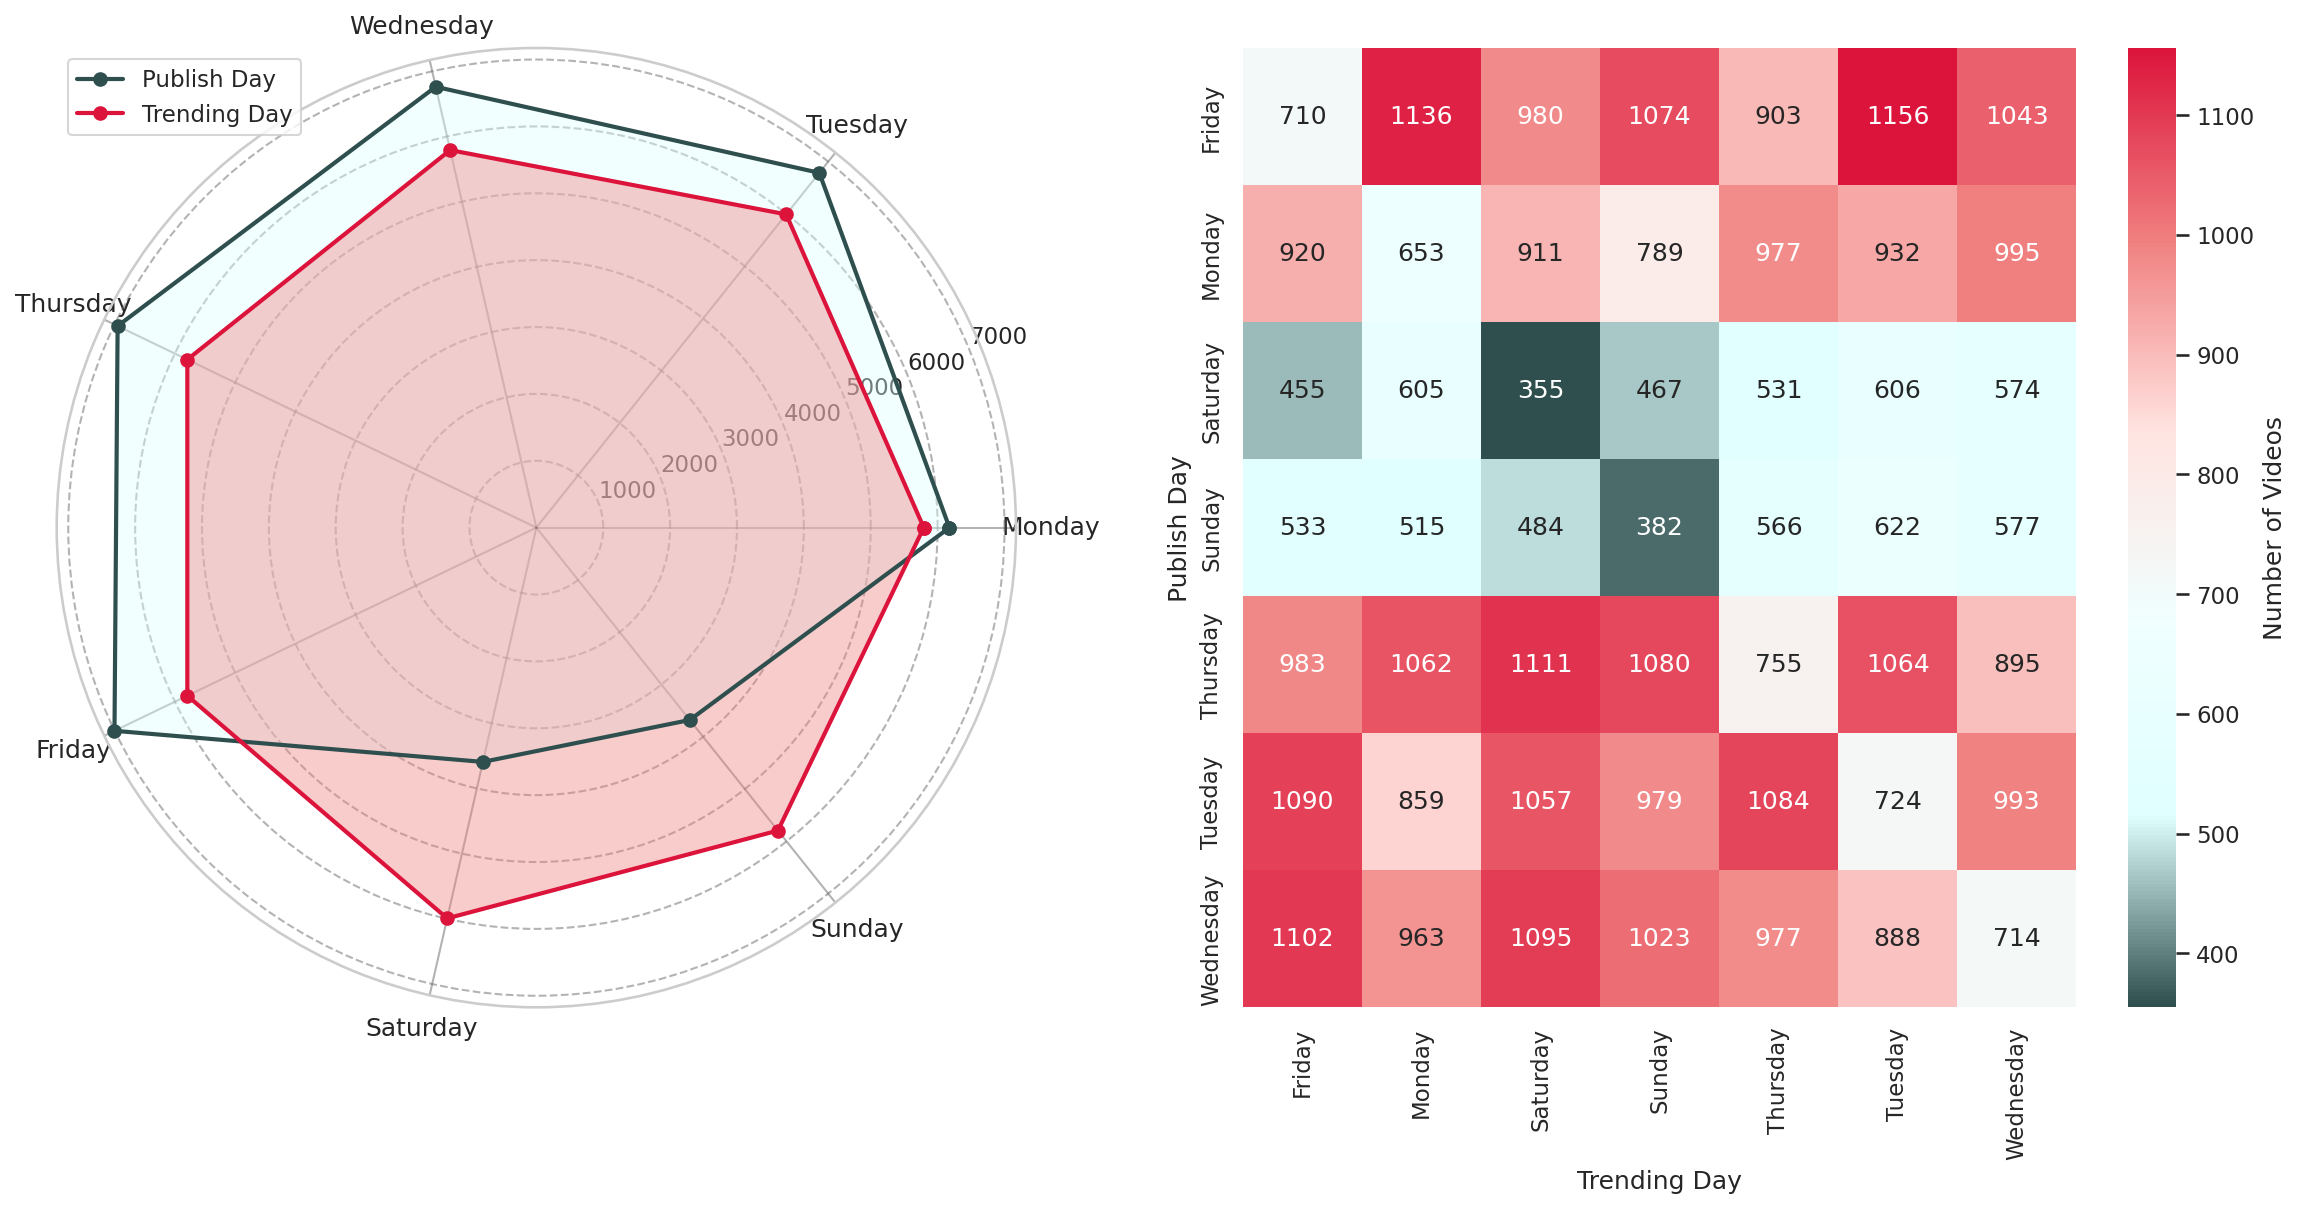

In [32]:
fig = plt.figure(figsize=(16, 8))

publish_day_counts = us_df['publish_day'].value_counts().reindex(days).fillna(0)
trending_day_counts = us_df['trending_day'].value_counts().reindex(days).fillna(0)

publish_values = publish_day_counts.values.tolist()
trending_values = trending_day_counts.values.tolist()

publish_values += publish_values[:1]
trending_values += trending_values[:1]

angles = np.linspace(0, 2 * np.pi, len(days), endpoint=False).tolist()
angles += angles[:1]

ax1 = fig.add_subplot(1, 2, 1, polar=True)

ax1.plot(angles, publish_values, color='darkslategrey', linewidth=2, marker='o', label='Publish Day')
ax1.fill(angles, publish_values, color='lightcyan', alpha=0.4)

ax1.plot(angles, trending_values, color='crimson', linewidth=2, marker='o', label='Trending Day')
ax1.fill(angles, trending_values, color='lightcoral', alpha=0.4)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(days, fontsize=12)

ax1.yaxis.grid(True, linestyle='--', alpha=0.5, color="dimgray")
ax1.xaxis.grid(True, linestyle='solid', alpha=0.3, color="black")

ax1.legend(loc='upper left')


heatmap_data = us_df.pivot_table(index='publish_day', columns='trending_day', aggfunc='size', fill_value=0)

ax2 = fig.add_subplot(1, 2, 2)

sns.heatmap(heatmap_data, ax=ax2, annot=True, fmt="d", cmap=nirnroot, cbar_kws={'label': 'Number of Videos'})

ax2.set_xlabel('Trending Day', labelpad=5)
ax2.set_ylabel('Publish Day')


fig_recorder.add(fig)

fig.tight_layout()
fig.show()

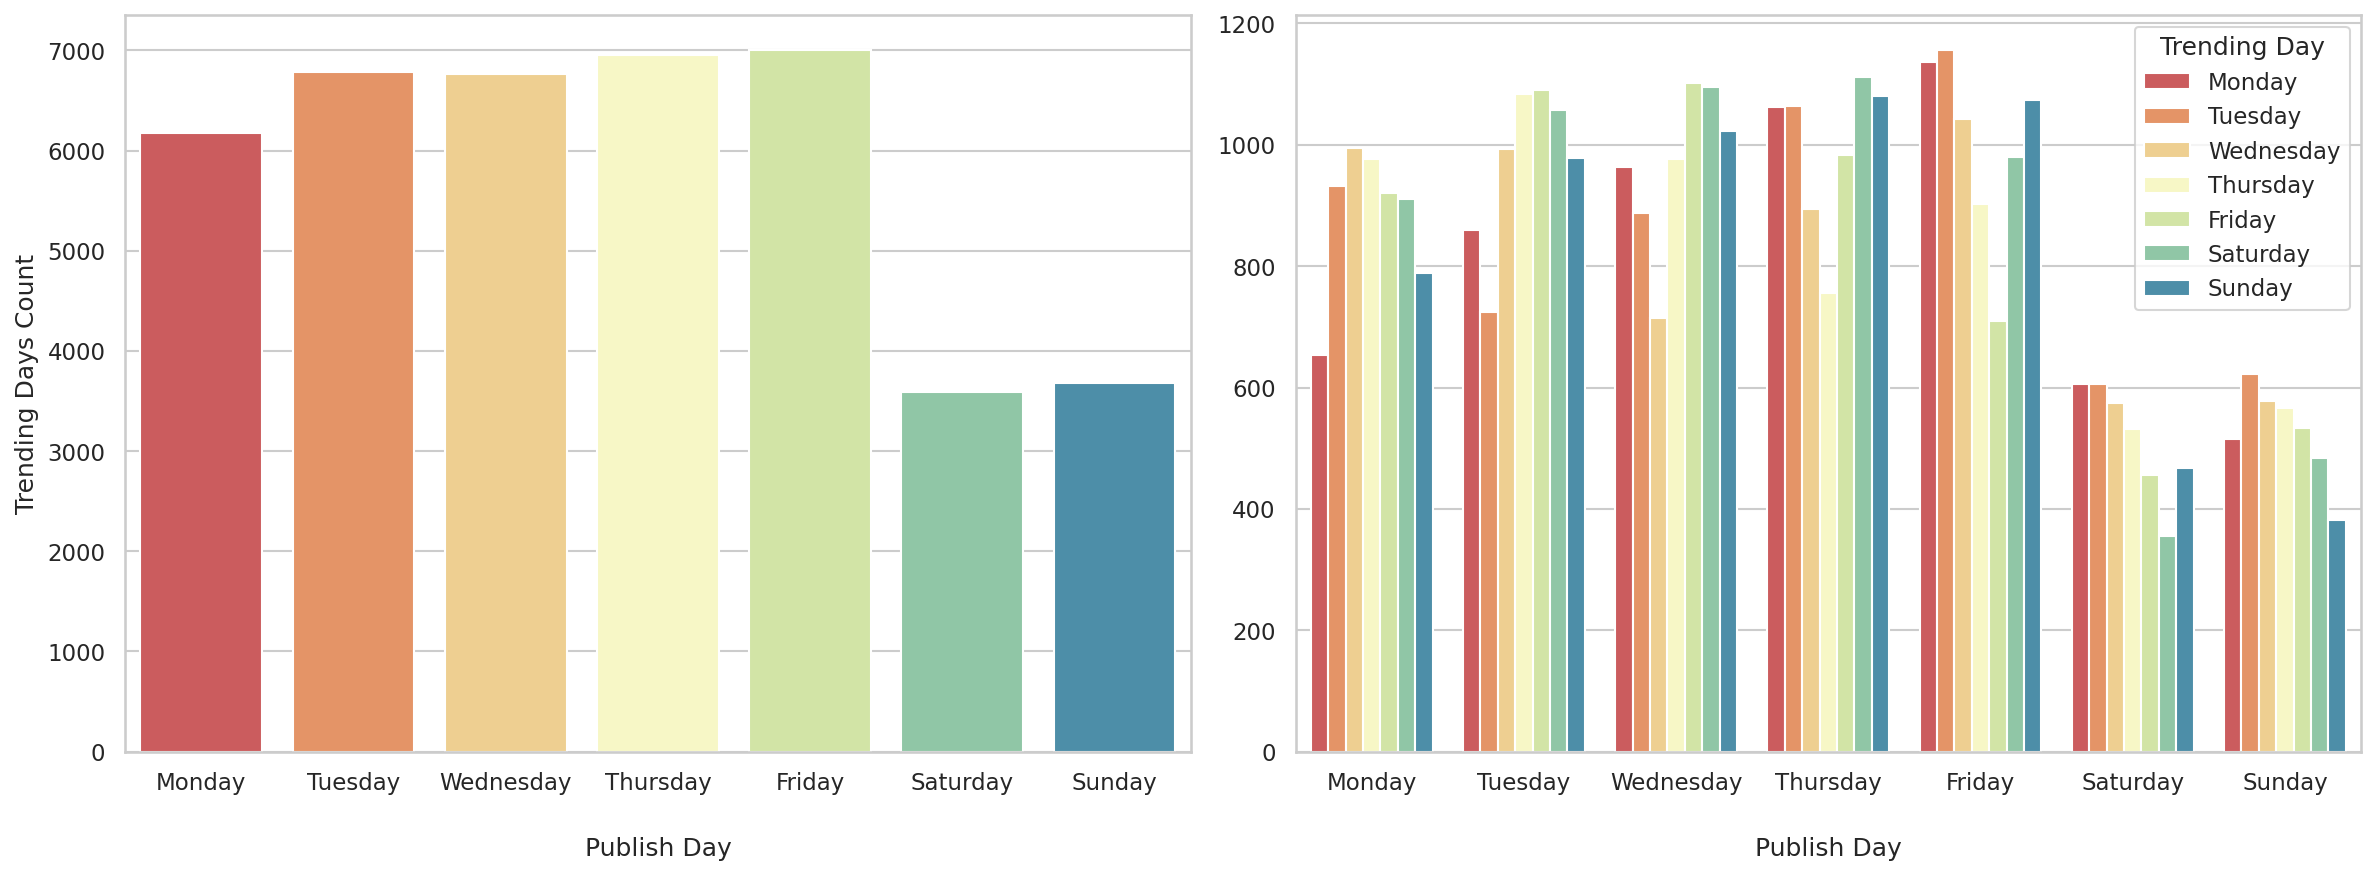

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

publish_trend_sum = us_df.groupby('publish_day')['trending_day'].count().reindex(days)

sns.barplot(ax=axes[0], x=publish_trend_sum.index, y=publish_trend_sum.values, palette='Spectral')
axes[0].set_xlabel('Publish Day', labelpad=20)
axes[0].set_ylabel('Trending Days Count')


combo_counts = us_df.groupby(['publish_day', 'trending_day']).size().reset_index(name='count')

combo_counts['publish_day'] = pd.Categorical(combo_counts['publish_day'], categories=days, ordered=True)
combo_counts['trending_day'] = pd.Categorical(combo_counts['trending_day'], categories=days, ordered=True)

sns.barplot(ax=axes[1], data=combo_counts, x='publish_day', y='count', hue='trending_day', palette='Spectral')
axes[1].set_xlabel('Publish Day', labelpad=20)
axes[1].set_ylabel("")
axes[1].legend(title='Trending Day', loc='upper right')

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

In [34]:
engagement_by_cat = [group['like_view_ratio'].dropna() for name, group in us_df.groupby('category') if len(group['like_view_ratio'].dropna()) > 20]
stat, p_val = kruskal(*engagement_by_cat)
print("Kruskal-Wallis H Test for Likes/Views Ratio across Categories")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("\n✅ There is a statistically significant difference in likes/views ratios across categories.")
else:
    print("\n❌ No significant difference found in likes/views ratios across categories.")

Kruskal-Wallis H Test for Likes/Views Ratio across Categories
Statistic: 9334.5691
p-value: 0.0000

✅ There is a statistically significant difference in likes/views ratios across categories.


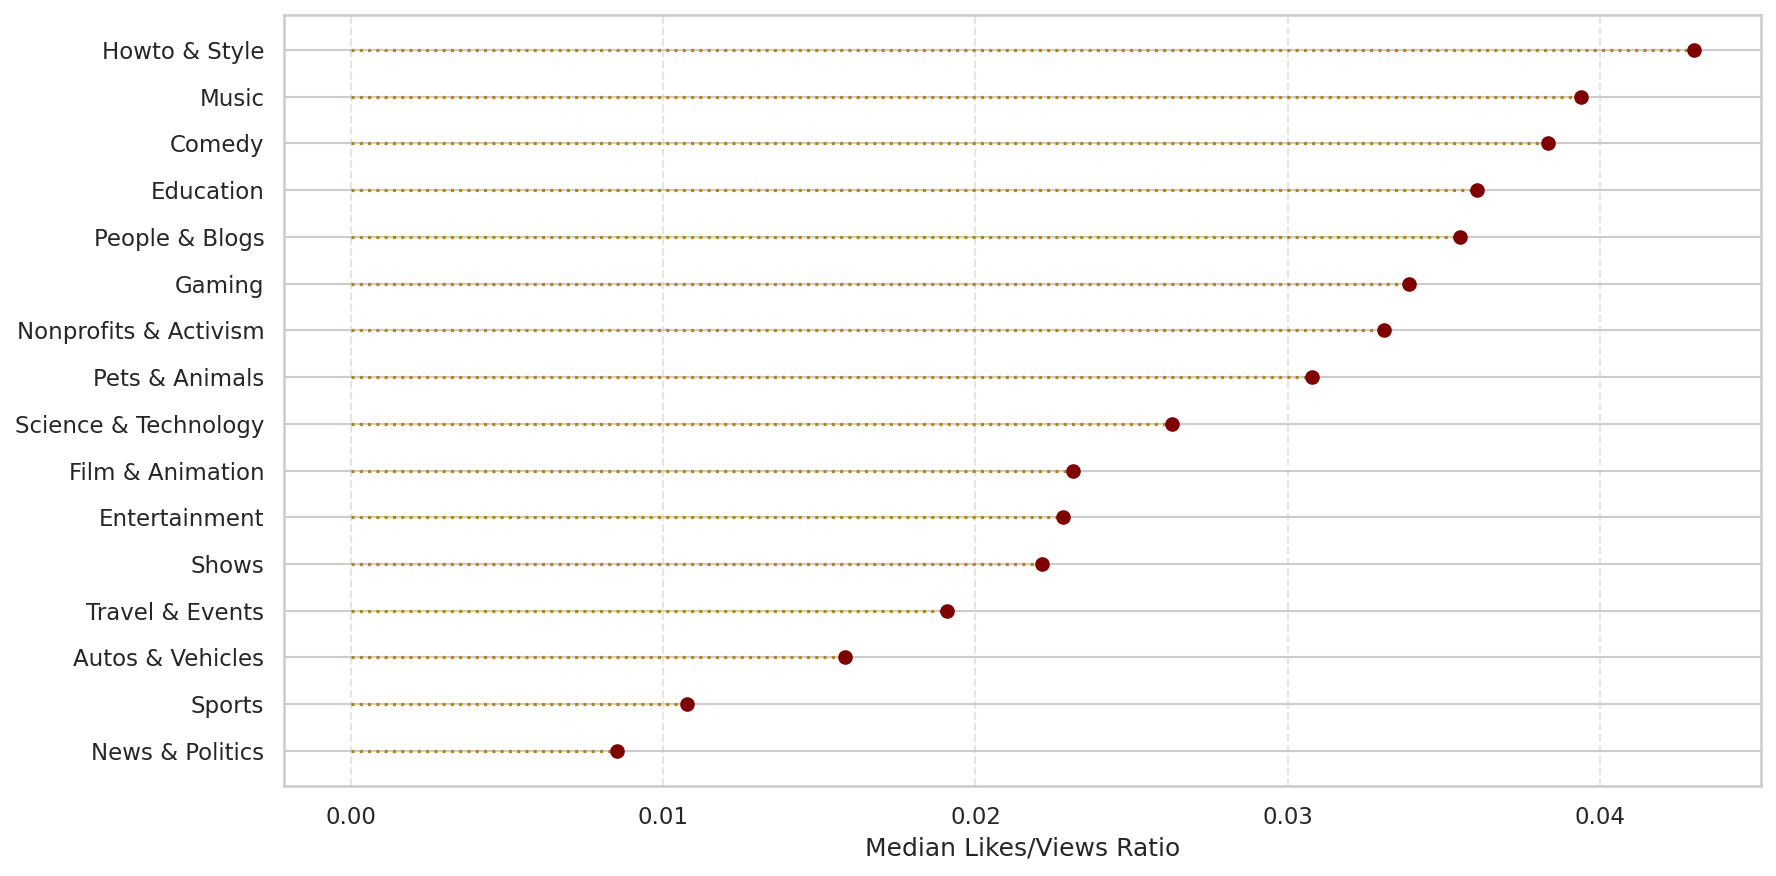

In [35]:
like_ratio_medians = us_df.groupby('category')['like_view_ratio'].median().dropna().sort_values()

fig = plt.figure()
plt.hlines(y=like_ratio_medians.index, xmin=0, xmax=like_ratio_medians.values, color='darkgoldenrod', linewidth=1.5, linestyles="dotted")
plt.plot(like_ratio_medians.values, like_ratio_medians.index, 'o', color='maroon')

plt.title("")
plt.xlabel("Median Likes/Views Ratio")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)

fig_recorder.add(fig)

fig.tight_layout()
fig.show()

In [36]:
fig_recorder.save_figures()